<div style="
    background-color: #e3f2fd; 
    border-left: 6px solid #2196f3; 
    padding: 15px; 
    border-radius: 4px; 
    color: #0d47a1;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
">
    <h2 style="margin-top: 0; color: #0d47a1; font-weight: 600;">Notebook: AI4EAC Health Practice Challenge</h2>
    <hr style="border: 0; border-top: 1px solid #90caf9; margin: 10px 0;">
    <p style="margin: 5px 0;"><strong>Created By:</strong> Ian Leboo</p>
    <p style="margin: 5px 0;"><strong>Date First Created:</strong> March 20, 2026</p>
    <p style="margin: 5px 0;"><strong>Date Last Updated:</strong> June 14, 2026</p>
</div>

# Background

The World Health Organization estimates that 1.3 million Kenyans suffer from untreated major depressive disorder (MDD; commonly known as depression) every year, and that sub-Saharan Africa has the highest prevalence of the illness of any region in the world. Yet mental health treatment in Kenya suffers from a lack of resources and stigmatization. There are only two certified psychiatrists per million people in Kenya. Few facilities exist outside of urban areas and people are unlikely to know about or access them.

In this task, we explore how machine learning cna be used to
The Busara Center for Behavioral Economics hosted a challenge the data science community in Nairobi, across Africa, and around the world to predict depression cases from routine survey data. This notebook showcases my approach to to solving the task, aiming to build a model which can accurately predict individuals that are likely to be depressed from the survey data. This could be used by mental health providers such as local clinics, NGOs or community health volunteers to reach out to those at risk.



## Challenge details
This challenge was hosted by Zindi [https://zindi.africa/competitions/the-ai4eac-health-practice-challenge],  This competition is hosted by the Busara Center for Behavioral Economics in partnership with AI Kenya, Women in Machine Learning and Data Science, Tulaa and ALX Launchpad.

In [3]:
# load required packages for data exploration and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# import train data
data = pd.read_csv('../data/train.csv')
# import test data
test_data = pd.read_csv('../data/test.csv')

# Exploratory Data Analysis

## Explore Data Characteristics

In [5]:
data.head()

,surveyid,village,survey_date,femaleres,age,married,children,hhsize,edu,hh_children,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
0,926,91,23-Nov-61,1,28.0,1,4,6,10,0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,5
1,747,57,24-Oct-61,1,23.0,1,3,5,8,0,...,0,0.0,1,4.804611,4.804611,0,0.000000,0,1,3
2,1190,115,05-Oct-61,1,22.0,1,3,5,9,0,...,0,0.0,0,8.007685,8.007685,1,0.000000,0,0,5
3,1065,97,23-Sep-61,1,27.0,1,2,4,10,2,...,0,0.0,0,0.000000,0.000000,1,1.249199,0,0,0
4,806,42,12-Sep-61,0,59.0,0,4,6,10,4,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,3


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 1143 non-null   int64  
 1   village                  1143 non-null   int64  
 2   survey_date              1143 non-null   object 
 3   femaleres                1143 non-null   int64  
 4   age                      1143 non-null   float64
 5   married                  1143 non-null   int64  
 6   children                 1143 non-null   int64  
 7   hhsize                   1143 non-null   int64  
 8   edu                      1143 non-null   int64  
 9   hh_children              1143 non-null   int64  
 10  hh_totalmembers          809 non-null    float64
 11  cons_nondurable          1143 non-null   float64
 12  asset_livestock          1143 non-null   float64
 13  asset_durable            1143 non-null   float64
 14  asset_phone             

In [7]:
# Shape of the data
data.shape

(1143, 75)

In [8]:
data.describe()

,surveyid,village,femaleres,age,married,children,hhsize,edu,hh_children,hh_totalmembers,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,809.000000,...,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,715.927384,76.409449,0.916885,34.537270,0.772528,2.860017,4.869641,8.735783,2.018373,4.906057,...,0.015748,0.553462,0.066492,3.564576,3.011114,0.188976,2.269096,0.097988,0.168854,3.295713
std,415.694525,66.788138,0.276176,13.742107,0.419383,1.846946,2.121852,2.867202,2.016702,2.099287,...,0.124554,6.489140,0.249249,24.950902,25.840639,0.391661,19.676268,0.297428,0.374787,1.684910
min,1.000000,1.000000,0.000000,17.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,-160.153700,0.000000,0.000000,0.000000,0.000000,0.000000
25%,351.500000,23.000000,1.000000,24.000000,1.000000,2.000000,3.000000,8.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,717.000000,57.000000,1.000000,30.000000,1.000000,3.000000,5.000000,9.000000,2.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,1078.500000,105.500000,1.000000,41.000000,1.000000,4.000000,6.000000,10.000000,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
max,1429.000000,292.000000,1.000000,91.000000,1.000000,10.000000,12.000000,19.000000,10.000000,12.000000,...,1.000000,160.153700,1.000000,352.338130,352.338130,1.000000,488.468780,1.000000,1.000000,6.000000


## Data pre-processing log to keep a record of columns dropped ata each stage

The function will help keep a log of variables that are dropped at each stage

In [9]:
from typing import Dict
import pandas as pd


class PreprocessingTracker:
    """Track and report variables excluded at each preprocessing step
    for a single dataset, producing a publication-ready summary table."""

    def __init__(self, initial_vars: int):
        """Initialize the tracker with the baseline column count."""
        self.initial_vars = initial_vars
        self.exclusions: Dict[str, int] = {}

    def log_exclusion(self, step_name: str, count: int) -> None:
        """Record the number of variables dropped in a specific step."""
        self.exclusions[step_name] = count

    def generate_table(self) -> pd.DataFrame:
        """Compile logs into a formatted summary DataFrame."""
        rows = []

        # 1. Baseline row
        rows.append(
            {"Pre-processing step": "Total available variables", "Count": self.initial_vars}
        )

        # 2. Individual preprocessing steps
        total_excluded = 0
        for step, count in self.exclusions.items():
            rows.append({"Pre-processing step": step, "Count": count})
            total_excluded += count

        # 3. Total excluded
        rows.append({"Pre-processing step": "Total excluded", "Count": total_excluded})

        # 4. Final remaining variables
        rows.append(
            {"Pre-processing step": "Final variables", "Count": self.initial_vars - total_excluded}
        )

        summary_df = pd.DataFrame(rows)
        return summary_df.set_index("Pre-processing step")

## Drop non-informative survey variables

In [10]:
# Record column count BEFORE dropping survey-level identifiers
initial_vars = data.shape[1]

# drop survey id, location and date values
cols_to_drop = ['surveyid', 'village', 'survey_date', 'day_of_week']
dropped_ids = [c for c in cols_to_drop if c in data.columns]
data.drop(columns=dropped_ids, inplace=True, errors='ignore')

# Initialize tracker with the pre-drop count
tracker = PreprocessingTracker(initial_vars=initial_vars)

# Log this step
tracker.log_exclusion("Survey identifiers (id, village, date, day_of_week)", len(dropped_ids))

# check log
# check pre-processing step report
pre_processing_report_table = tracker.generate_table()
print(pre_processing_report_table)

                                                    Count
Pre-processing step                                      
Total available variables                              75
Survey identifiers (id, village, date, day_of_w...      4
Total excluded                                          4
Final variables                                        71


## Demographic Characteristics of Respondents

In [11]:
import tableone
from tableone import TableOne

# define respondet demographics
demographics_vars = [
    "femaleres",
    "age",
    "married",
    "children",
    "hhsize",
    "edu",
    "hh_children",
    "hh_totalmembers"
]

# define categorical variables
categorical_vars = [
    "femaleres",
    "married"
]

table = TableOne(
    data,
    columns=demographics_vars,
    categorical=categorical_vars
)

print(table.tabulate(tablefmt="fancy_grid"))

╒════════════════════════════╤════╤═══════════╤═════════════╕
│                            │    │   Missing │ Overall     │
╞════════════════════════════╪════╪═══════════╪═════════════╡
│ n                          │    │           │ 1143        │
├────────────────────────────┼────┼───────────┼─────────────┤
│ femaleres, n (%)           │  0 │           │ 95 (8.3)    │
├────────────────────────────┼────┼───────────┼─────────────┤
│                            │  1 │           │ 1048 (91.7) │
├────────────────────────────┼────┼───────────┼─────────────┤
│ age, mean (SD)             │    │         0 │ 34.5 (13.7) │
├────────────────────────────┼────┼───────────┼─────────────┤
│ married, n (%)             │  0 │           │ 260 (22.7)  │
├────────────────────────────┼────┼───────────┼─────────────┤
│                            │  1 │           │ 883 (77.3)  │
├────────────────────────────┼────┼───────────┼─────────────┤
│ children, mean (SD)        │    │         0 │ 2.9 (1.8)   │
├───────

In [12]:
# stratify by depression status
table = TableOne(
    data,
    columns=demographics_vars,
    categorical=categorical_vars,
    groupby="depressed"
)

print(table.tabulate(tablefmt="fancy_grid"))

╒════════════════════════════╤════╤═══════════╤═════════════╤═════════════╤═════════════╕
│                            │    │   Missing │ Overall     │ 0           │ 1           │
╞════════════════════════════╪════╪═══════════╪═════════════╪═════════════╪═════════════╡
│ n                          │    │           │ 1143        │ 950         │ 193         │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│ femaleres, n (%)           │  0 │           │ 95 (8.3)    │ 78 (8.2)    │ 17 (8.8)    │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│                            │  1 │           │ 1048 (91.7) │ 872 (91.8)  │ 176 (91.2)  │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│ age, mean (SD)             │    │         0 │ 34.5 (13.7) │ 33.9 (13.2) │ 37.6 (15.7) │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│ married,

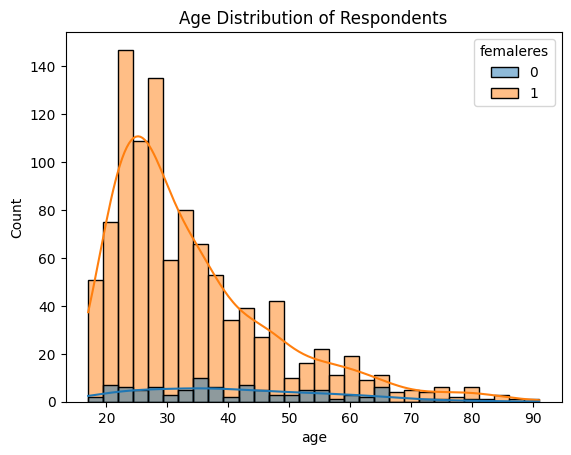

In [13]:
# distribution of age

sns.histplot(data = data, x = "age", bins=30, kde=True, hue="femaleres")
plt.title("Age Distribution of Respondents")
plt.show()

C:\Users\Ian Leboo\AppData\Local\Temp\ipykernel_1240\4239133835.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender = data.groupby(['age_group', 'femaleres']).size().unstack(fill_value=0)


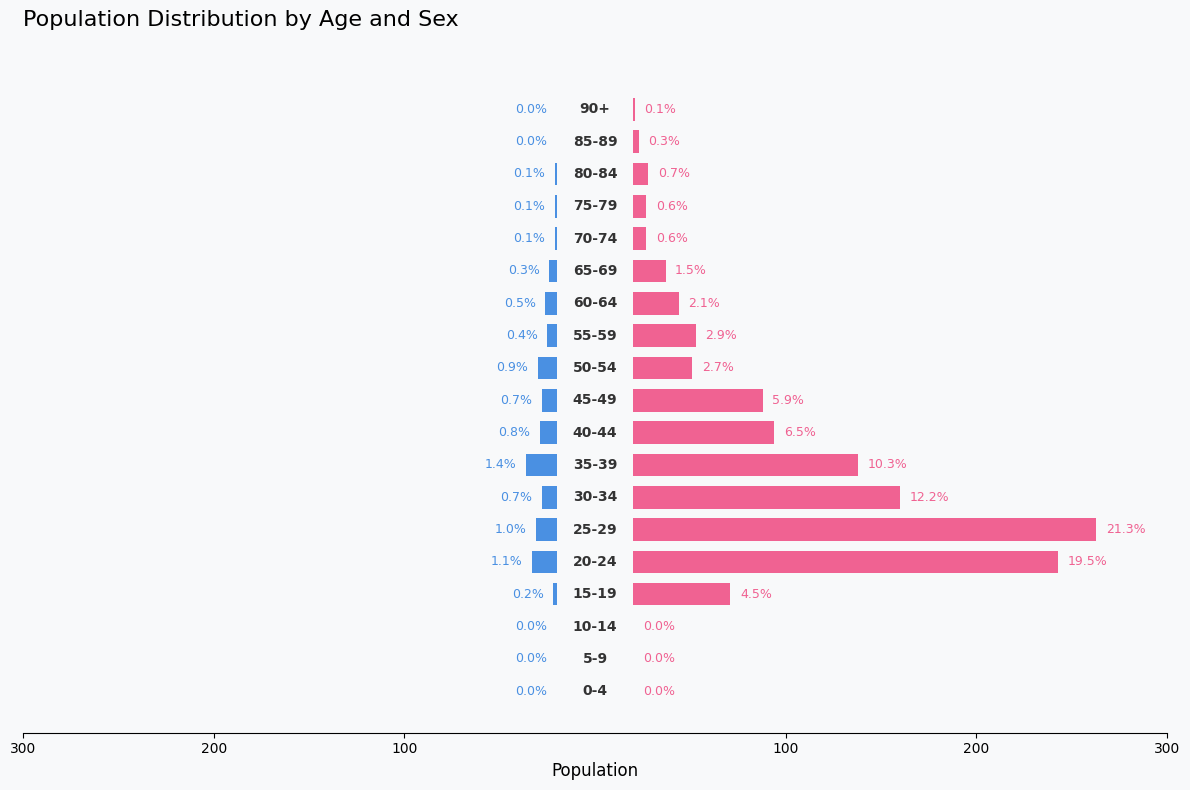

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data (assuming 'data' exists)
bins = list(range(0, 91, 5)) + [100]
labels = [f'{i}-{i+4}' for i in range(0, 86, 5)] + ['90+']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)

# Group by age group and gender (0=Male, 1=Female)
age_gender = data.groupby(['age_group', 'femaleres']).size().unstack(fill_value=0)

# Calculate Percentages
total_pop = age_gender.values.sum()
age_gender_pct = (age_gender / total_pop) * 100

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

y = range(len(age_gender))
males = age_gender[0]
females = age_gender[1]
m_pct = age_gender_pct[0]
f_pct = age_gender_pct[1]

# 3. Draw Bars
# We use a gap in the middle for the labels by shifting bars left/right
offset = 20  # Space for the center labels
ax.barh(y, -males, color='#4A90E2', label='Male', height=0.7, left=-offset)
ax.barh(y, females, color='#F06292', label='Female', height=0.7, left=offset)

# 4. Add Age Group Labels in the center
for i, label in enumerate(age_gender.index):
    ax.text(0, i, label, ha='center', va='center', fontsize=10, fontweight='bold', color='#333')

# 5. Add Percentage Annotations
for i, (m, f, mp, fp) in enumerate(zip(males, females, m_pct, f_pct)):
    # Male percentages (left)
    ax.text(-m - offset - 5, i, f'{mp:.1f}%', ha='right', va='center', color='#4A90E2', fontsize=9)
    # Female percentages (right)
    ax.text(f + offset + 5, i, f'{fp:.1f}%', ha='left', va='center', color='#F06292', fontsize=9)

# 6. Styling
ax.set_title("Population Distribution by Age and Sex", fontsize=16, pad=30, loc='left')
ax.set_xlabel("Population", fontsize=12)

# Format X-axis to show positive numbers and hide the 0 center
ax.set_xticks([-300, -200, -100, 100, 200, 300])
ax.set_xticklabels(['300', '200', '100', '100', '200', '300'])

# Clean up chart borders
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.get_yaxis().set_visible(False) # Hide default y-axis

plt.tight_layout()
plt.show()


## Household economics / assets
We examine asset ownership/value and consumption/expenditure patterns, stratified by depression status (`depressed`).
Most expenditure variables are right-skewed (USD amounts), so we use boxplots on a log1p scale alongside TableOne summaries.

In [15]:
# define variable groups for household economics

assets_vars = [
    "asset_livestock",
    "asset_durable",
    "asset_phone",
    "asset_savings",
    "asset_land_owned_total",
    "asset_niceroof",
    "durable_investment",
    "nondurable_investment"
]

assets_categorical = ["asset_niceroof"]

consumption_vars = [
    "cons_nondurable",
    "cons_allfood",
    "cons_ownfood",
    "cons_alcohol",
    "cons_tobacco",
    "cons_med_total",
    "cons_med_children",
    "cons_ed",
    "cons_social",
    "cons_other"
]

In [16]:
# Assets - Table one stratified by depression status

table_assets = TableOne(
    data, 
    columns=assets_vars,
    categorical=assets_categorical,
    groupby="depressed",
    pval=True
)

print(table_assets.tabulate(tablefmt="fancy_grid"))

╒═══════════════════════════════════╤════╤═══════════╤═══════════════╤═══════════════╤═══════════════╤═══════════╕
│                                   │    │   Missing │ Overall       │ 0             │ 1             │   P-Value │
╞═══════════════════════════════════╪════╪═══════════╪═══════════════╪═══════════════╪═══════════════╪═══════════╡
│ n                                 │    │           │ 1143          │ 950           │ 193           │           │
├───────────────────────────────────┼────┼───────────┼───────────────┼───────────────┼───────────────┼───────────┤
│ asset_livestock, mean (SD)        │    │         0 │ 113.7 (239.7) │ 111.5 (218.6) │ 124.4 (324.6) │     0.598 │
├───────────────────────────────────┼────┼───────────┼───────────────┼───────────────┼───────────────┼───────────┤
│ asset_durable, mean (SD)          │    │         0 │ 148.6 (198.4) │ 152.8 (207.4) │ 127.8 (145.1) │     0.045 │
├───────────────────────────────────┼────┼───────────┼───────────────┼──────────

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


**Table 2: Household Assets by Depression Status**

Bivariate comparisons of household asset variables by depression status (Table 2) showed that mean durable asset value was significantly lower among respondents classified as depressed (USD 127.8, SD 145.1) compared to non-depressed respondents (USD 152.8, SD 207.4; p = 0.045). Similarly, mean non-durable investment was significantly lower in the depressed group (USD 24.0, SD 47.3) relative to the non-depressed group (USD 36.6, SD 145.4; p = 0.031).

No statistically significant differences were observed between groups for livestock value (p = 0.598), phone value (p = 0.218), savings (p = 0.436), total land owned (p = 0.731), or durable investment (p = 0.615).

The variable asset_niceroof was found to be near-constant across the sample (99.9% = 1), with only a single observation in the reference category, precluding meaningful statistical comparison; this variable was therefore excluded from further analysis.

These findings suggest a modest bivariate association between depression status and indicators of household economic capacity, specifically reduced asset accumulation and lower levels of investment. However, given the number of variables examined, the possibility of false-positive associations arising from multiple comparisons cannot be excluded, and these effects should be interpreted as exploratory pending multivariate analysis.


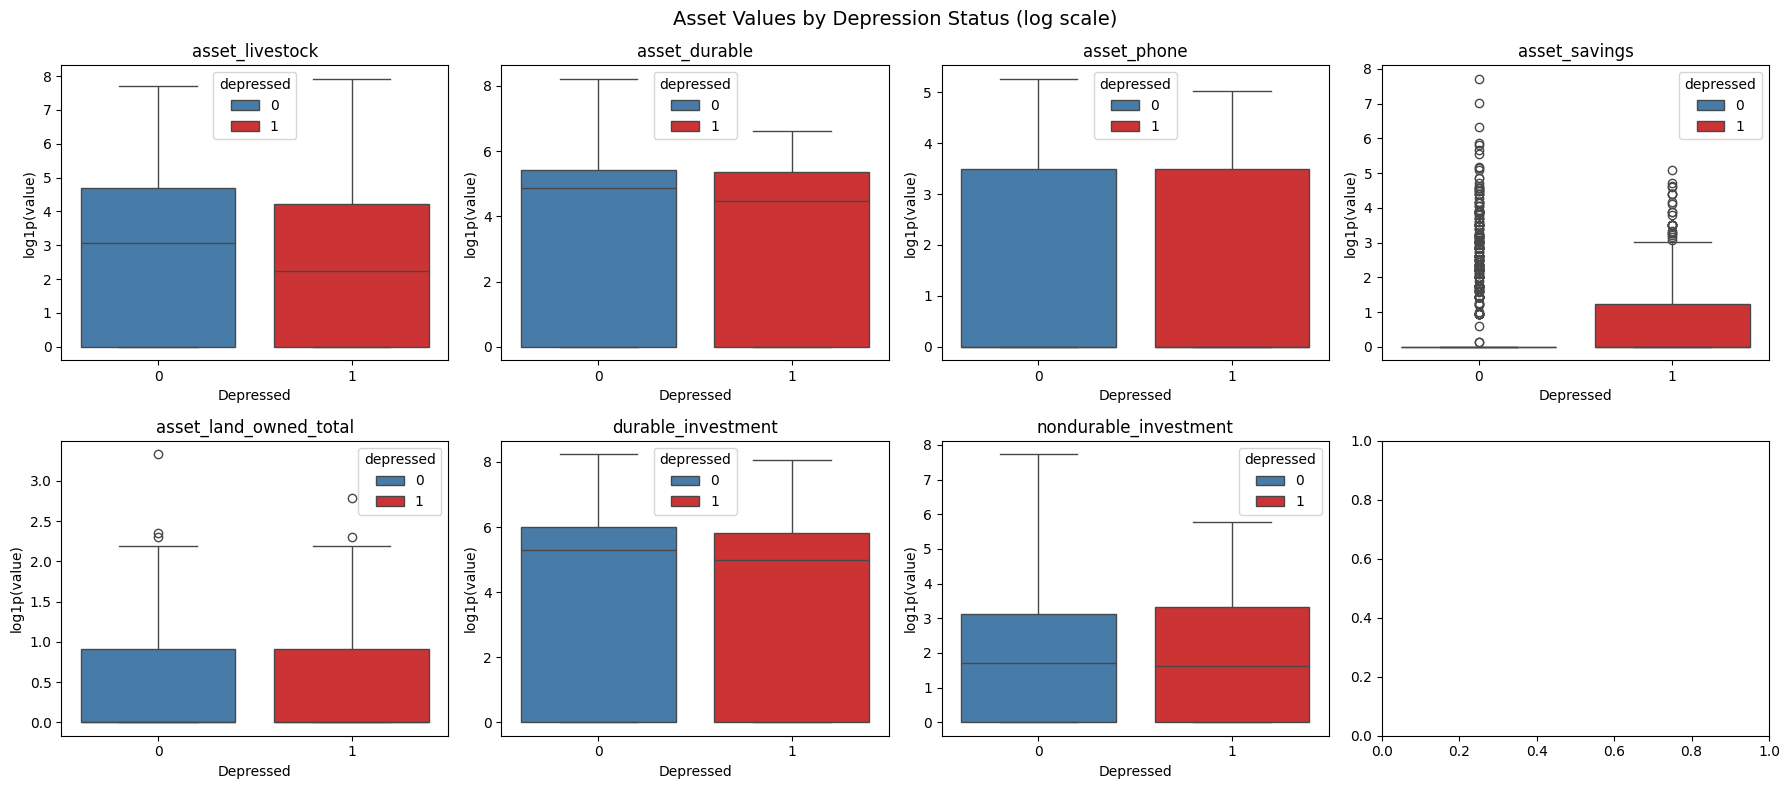

In [17]:
# Boxplots: continuous asset variables (log1p scale) by depression status

color_mapping = {0: sns.color_palette("Set1")[1], 1: sns.color_palette("Set1")[0]} # Dictionary mapping the exact Set 1 colors in reverse order - Set1[1] is Blue (#377eb8), Set1[0] is Red (#e41a1c)

assets_continuous = [v for v in assets_vars if v not in assets_categorical]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(assets_continuous):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")

plt.suptitle("Asset Values by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()

## Household Consumption and Expenditure Patterns by Depression Status

In [18]:
# Consumption / expenditure - Table one stratified by depression status

table_consumption = TableOne(
    data,
    columns=consumption_vars,
    groupby="depressed",
    pval=True
)

print(table_consumption.tabulate(tablefmt="fancy_grid"))

╒══════════════════════════════╤════╤═══════════╤═══════════════╤═══════════════╤═══════════════╤═══════════╕
│                              │    │   Missing │ Overall       │ 0             │ 1             │   P-Value │
╞══════════════════════════════╪════╪═══════════╪═══════════════╪═══════════════╪═══════════════╪═══════════╡
│ n                            │    │           │ 1143          │ 950           │ 193           │           │
├──────────────────────────────┼────┼───────────┼───────────────┼───────────────┼───────────────┼───────────┤
│ cons_nondurable, mean (SD)   │    │         0 │ 128.4 (140.2) │ 129.7 (142.4) │ 121.9 (128.8) │     0.453 │
├──────────────────────────────┼────┼───────────┼───────────────┼───────────────┼───────────────┼───────────┤
│ cons_allfood, mean (SD)      │    │         0 │ 95.8 (114.5)  │ 96.9 (117.3)  │ 90.3 (99.6)   │     0.417 │
├──────────────────────────────┼────┼───────────┼───────────────┼───────────────┼───────────────┼───────────┤
│ cons_own

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


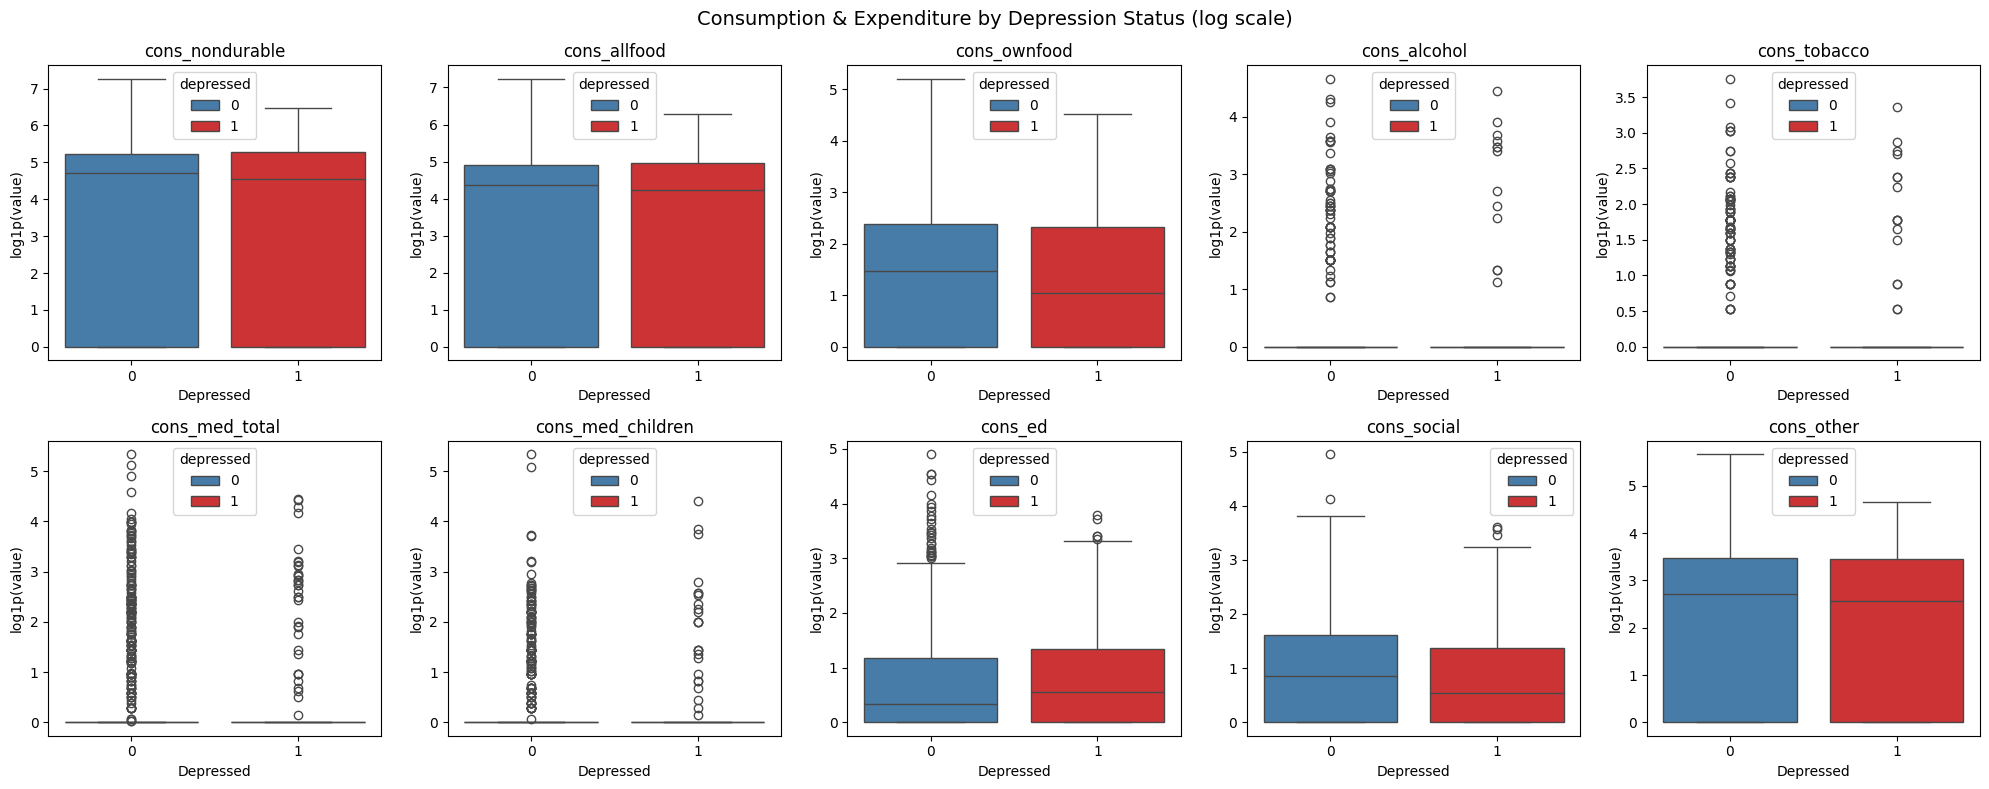

In [19]:
# Boxplots: consumption / expenditure variables (log1p scale) by depression status

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(consumption_vars):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")

plt.suptitle("Consumption & Expenditure by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()

**Table 3: Household Consumption and Expenditure Patterns by Depression Status**

Bivariate comparisons of consumption and expenditure variables by depression status (Table 3) showed no statistically significant differences between groups for any of the variables examined. Mean non-durable consumption was similar between depressed (USD 121.9, SD 128.8) and non-depressed respondents (USD 129.7, SD 142.4; p = 0.453), as was total food expenditure (USD 90.3 vs USD 96.9; p = 0.417) and own-produced food consumption (USD 7.6 vs USD 8.5; p = 0.402).

Expenditure on alcohol (p = 0.259) and tobacco (p = 0.811) did not differ significantly by depression status, despite slightly higher mean values among depressed respondents (alcohol: USD 1.8 vs USD 1.0; tobacco: USD 0.7 vs USD 0.6). Medical expenditure, both for the household overall (p = 0.441) and for children specifically (p = 0.431), also showed no significant association, again with marginally higher values in the depressed group.

Expenditure on education (p = 0.817), social activities (p = 0.509), and other categories (p = 0.199) likewise did not differ significantly between groups.

Two variables — `cons_alcohol` (43 missing) and `cons_med_children` (419 missing) — had substantial missingness, with `cons_med_children` missing for over a third of the sample; this should be accounted for during preprocessing (e.g., explicit missingness indicators or imputation strategy).

Overall, consumption and expenditure patterns showed no statistically significant univariate associations with depression status in this sample. While several point estimates trend in directions consistent with prior literature (e.g., slightly elevated alcohol and medical expenditure among depressed respondents), these differences were not significant at the conventional threshold and should not be interpreted as evidence of association absent multivariate confirmation.


## Income / Enterprise

In [20]:
# Group 3: Income / Enterprise (Livelihoods)
income_vars = [
    "ent_wagelabor",
    "ent_ownfarm",
    "ent_business",
    "ent_nonagbusiness",
    "ent_employees",
    "ent_nonag_revenue",
    "ent_nonag_flowcost",
    "ent_farmrevenue",
    "ent_farmexpenses",
    "ent_animalstockrev",
    "ent_total_cost",
    "labor_primary",
    "wage_expenditures"
]

income_categorical = [
    "ent_wagelabor",
    "ent_ownfarm",
    "ent_business",
    "ent_nonagbusiness",
    "labor_primary"
]

# Group 4: Food Security
foodsec_vars = [
    "fs_adskipm_often",
    "fs_adwholed_often",
    "fs_chskipm_often",
    "fs_chwholed_often",
    "fs_meat",
    "fs_enoughtom",
    "fs_sleephun"
]

foodsec_categorical = [
    "fs_enoughtom",
    "fs_sleephun"
]

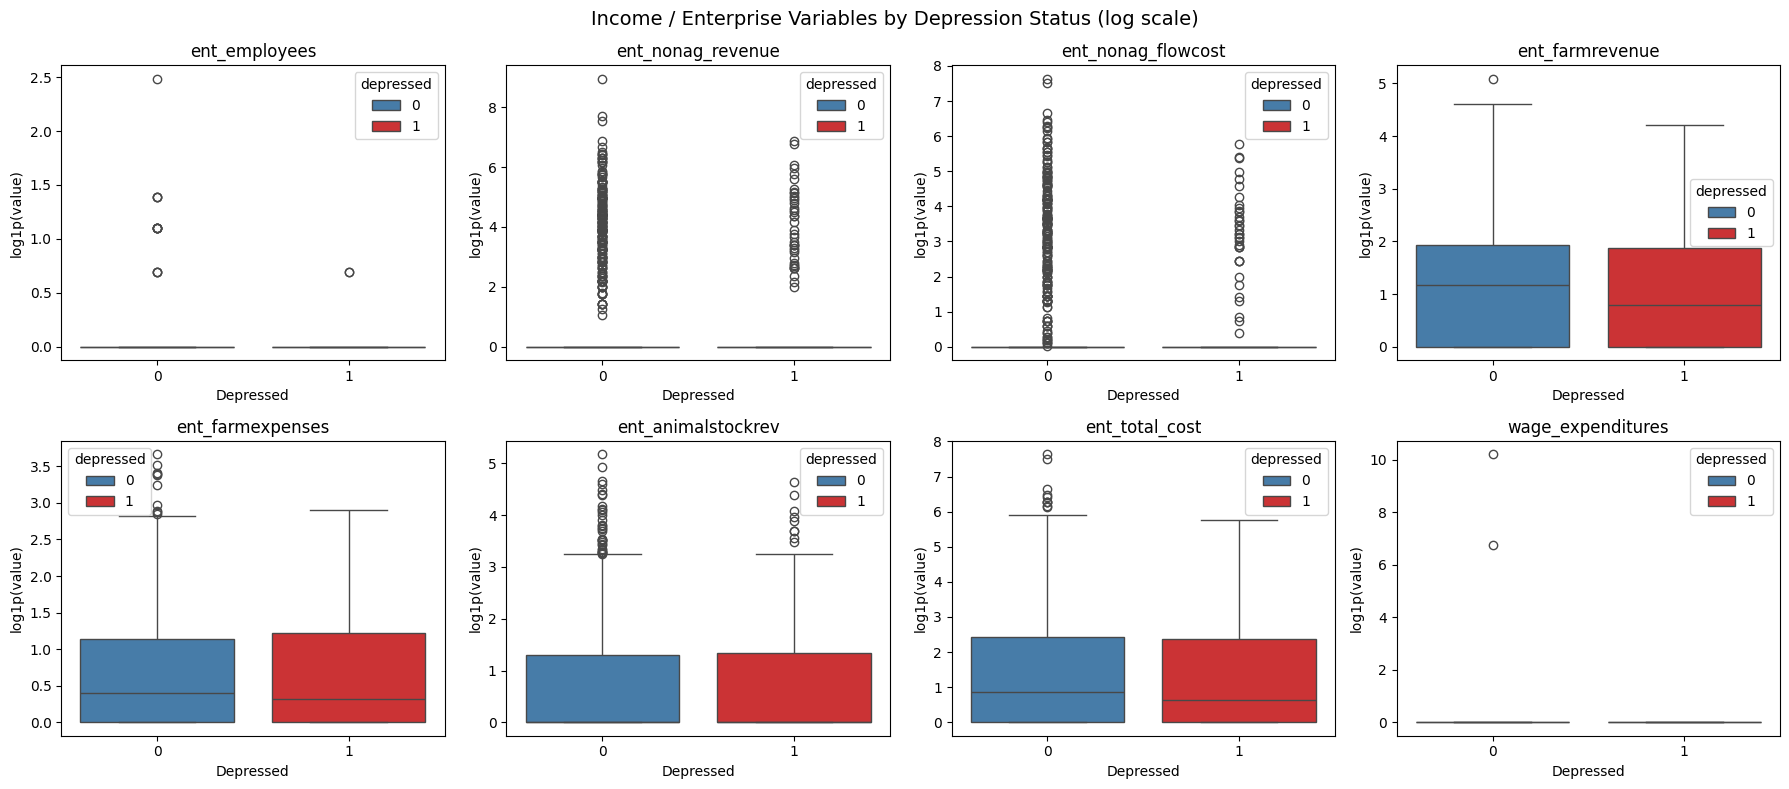

In [21]:
# boxplots: income / enterprise variables (log1p scale) by depression status
income_continuous = [v for v in income_vars if v not in income_categorical]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

   
for i, col in enumerate(income_continuous):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")
 
# hide unused subplot if any
for j in range(len(income_continuous), len(axes)):
    axes[j].set_visible(False)
        
plt.suptitle("Income / Enterprise Variables by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
table_income = TableOne(
    data,
    columns=income_vars,
    categorical=income_categorical,
    groupby="depressed",
    pval=True
)

print(table_income.tabulate(tablefmt="fancy_grid"))

╒═══════════════════════════════╤════╤═══════════╤══════════════╤══════════════╤══════════════╤═══════════╕
│                               │    │   Missing │ Overall      │ 0            │ 1            │   P-Value │
╞═══════════════════════════════╪════╪═══════════╪══════════════╪══════════════╪══════════════╪═══════════╡
│ n                             │    │           │ 1143         │ 950          │ 193          │           │
├───────────────────────────────┼────┼───────────┼──────────────┼──────────────┼──────────────┼───────────┤
│ ent_wagelabor, n (%)          │  0 │           │ 930 (81.4)   │ 773 (81.4)   │ 157 (81.3)   │     1     │
├───────────────────────────────┼────┼───────────┼──────────────┼──────────────┼──────────────┼───────────┤
│                               │  1 │           │ 213 (18.6)   │ 177 (18.6)   │ 36 (18.7)    │           │
├───────────────────────────────┼────┼───────────┼──────────────┼──────────────┼──────────────┼───────────┤
│ ent_ownfarm, n (%)        

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


**Table 4: Income and Enterprise (Livelihood) Characteristics by Depression Status**

Bivariate comparisons of income source and enterprise variables by depression status (Table 4) revealed no significant differences in the proportion of households reporting wage labor (18.6% vs 18.7%, p = 1.000), farm ownership (24.9% vs 23.8%, p = 0.814), non-agricultural business ownership as primary income (11.1% vs 9.3%, p = 0.563), or non-agricultural business ownership generally (27.3% vs 25.4%, p = 0.656) as primary income source. The proportion reporting wage/casual labor as primary income source (`labor_primary`) was also similar between groups (22.2% vs 21.8%, p = 0.967).

Two enterprise expenditure variables showed statistically significant differences. Mean non-agricultural business flow costs were significantly lower among depressed respondents (USD 9.4, SD 36.0) compared to non-depressed respondents (USD 18.9, SD 109.0; p = 0.029). Similarly, mean total enterprise costs were significantly lower in the depressed group (USD 12.9, SD 37.1) relative to the non-depressed group (USD 23.1, SD 109.9; p = 0.022).

The number of employees in non-agricultural businesses showed a borderline non-significant difference (0.0 vs 0.0, p = 0.092), with depressed respondents reporting near-zero employees. Farm revenue (p = 0.337), farm expenses (p = 0.558), livestock/animal stock revenue (p = 0.525), non-agricultural business revenue (p = 0.454), and wage expenditures (p = 0.303) did not differ significantly between groups.

Of note, `wage_expenditures` showed a mean of USD 0.0 (SD 0.0) among depressed respondents, despite an overall mean of USD 24.4 (SD 799.0) — indicating that no depressed respondent in this sample reported any wage expenditure, while the overall distribution is driven by extreme outliers in the non-depressed group (SD far exceeding the mean). This variable should be examined for outlier influence before any further use.

Overall, the pattern of significant findings — lower business operating costs and total enterprise costs among depressed respondents — is consistent with the asset/investment findings from Table 2, reinforcing a tentative theme of **reduced economic activity and engagement** associated with depression status. However, as with previous tables, the high variance and skewness of these monetary variables, combined with multiple comparisons across many variables, warrant caution in interpretation pending multivariate analysis.

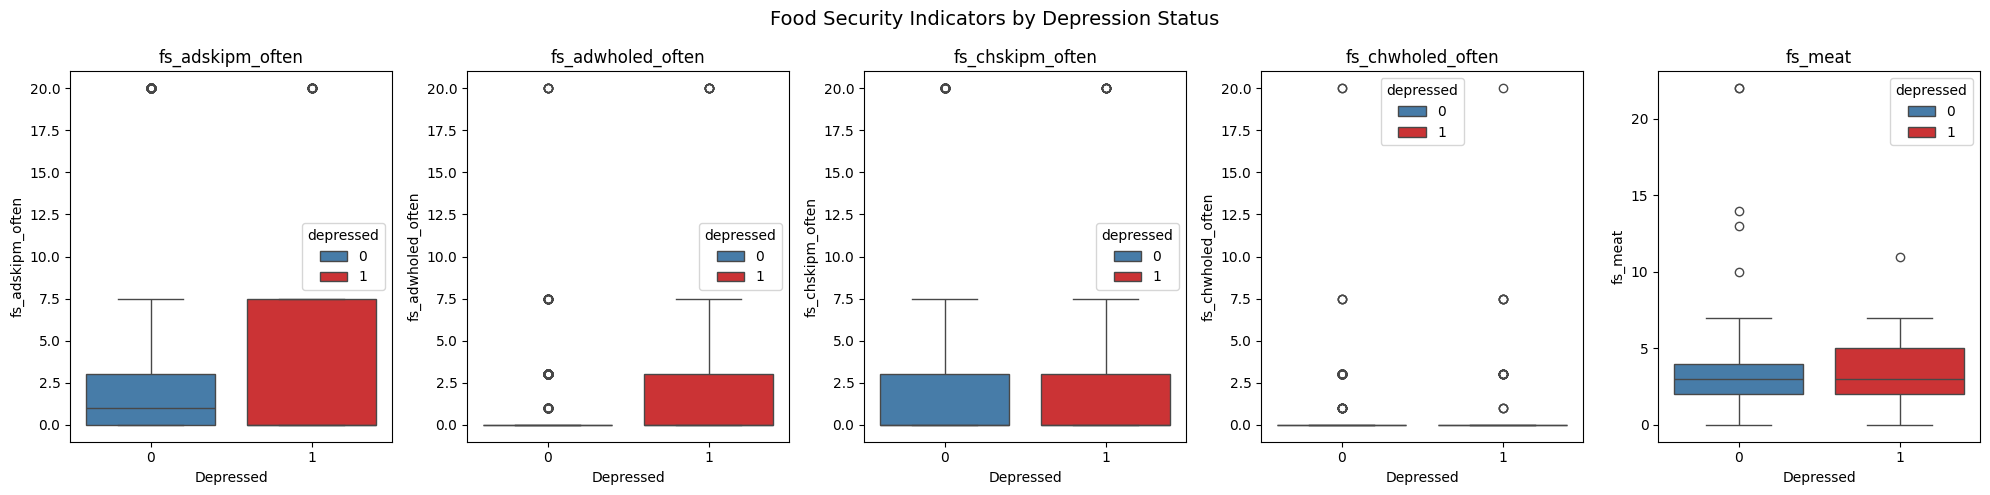

In [23]:
foodsec_continuous = [v for v in foodsec_vars if v not in foodsec_categorical]

fig, axes = plt.subplots(1, len(foodsec_continuous), figsize=(20, 5))

for i, col in enumerate(foodsec_continuous):
    sns.boxplot(data=data, x="depressed", y=col, ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_xlabel("Depressed")

plt.suptitle("Food Security Indicators by Depression Status", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
table_foodsec = TableOne(
    data,
    columns=foodsec_vars,
    categorical=foodsec_categorical,
    groupby="depressed",
    pval=True
)

print(table_foodsec.tabulate(tablefmt="fancy_grid"))

╒══════════════════════════════╤══════╤═══════════╤════════════╤════════════╤═══════════╤═══════════╕
│                              │      │   Missing │ Overall    │ 0          │ 1         │   P-Value │
╞══════════════════════════════╪══════╪═══════════╪════════════╪════════════╪═══════════╪═══════════╡
│ n                            │      │           │ 1143       │ 950        │ 193       │           │
├──────────────────────────────┼──────┼───────────┼────────────┼────────────┼───────────┼───────────┤
│ fs_adskipm_often, mean (SD)  │      │         0 │ 4.0 (6.2)  │ 4.0 (6.2)  │ 4.3 (6.6) │     0.614 │
├──────────────────────────────┼──────┼───────────┼────────────┼────────────┼───────────┼───────────┤
│ fs_adwholed_often, mean (SD) │      │         0 │ 0.9 (2.6)  │ 0.7 (2.2)  │ 1.7 (4.0) │     0.001 │
├──────────────────────────────┼──────┼───────────┼────────────┼────────────┼───────────┼───────────┤
│ fs_chskipm_often, mean (SD)  │      │       416 │ 2.9 (5.3)  │ 2.8 (5.1)  │ 3.5 

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


**Table 5: Food Security Indicators by Depression Status**

Bivariate comparisons of food security indicators by depression status (Table 5) revealed a statistically significant difference in the number of whole days without food among adults in the past month. Depressed respondents reported a substantially higher mean (1.7, SD 4.0) compared to non-depressed respondents (0.7, SD 2.2; p = 0.001).

A borderline non-significant difference was observed for whole days without food among children, with depressed respondents reporting a higher mean (0.8, SD 2.4) than non-depressed respondents (0.4, SD 1.5; p = 0.053).

The number of meals skipped by adults in the past month did not differ significantly between groups (4.3 vs 4.0, p = 0.614), nor did meals skipped by children (3.5 vs 2.8, p = 0.234), frequency of meat/fish consumption in the past week (3.2 vs 3.0, p = 0.472), reported sufficiency of food for the following day (`fs_enoughtom`, p = 0.319), or whether the respondent slept hungry in the past week (`fs_sleephun`, p = 0.165).

Both `fs_enoughtom` and `fs_chskipm_often`/`fs_chwholed_often`/`fs_fs_chwholed_often` and related child food security variables had substantial missingness (334-416 missing, roughly 29-36% of the sample), with `None` appearing as a distinct category for `fs_enoughtom` and `fs_sleephun` rather than being treated as missing in TableOne's categorical breakdown — this should be reconciled during preprocessing (i.e., confirm whether `None` represents true missingness or a valid "don't know"/non-response category, and handle consistently with the continuous food security variables' missingness).

Overall, the most notable finding in this domain is the significant association between **adult food deprivation (whole days without food)** and depression status, with depressed respondents experiencing more than double the mean number of food-deprived days relative to non-depressed respondents. This is consistent with the broader pattern observed across economic indicators (Tables 2 and 4), suggesting that depression in this sample co-occurs with markers of more severe material hardship, distinct from routine consumption or income-source variables which showed weaker associations.


## Medical expenditure vs depression status

In [25]:
# Group 5: Medical / Health
medical_vars = [
    "med_expenses_hh_ep",
    "med_expenses_sp_ep",
    "med_expenses_child_ep",
    "med_portion_sickinjured",
    "med_port_sick_child",
    "med_afford_port",
    "med_sickdays_hhave",
    "med_healthconsult",
    "med_vacc_newborns",
    "med_child_check",
    "med_u5_deaths"
]

# all are proportions/continuous - none are simple 0/1 dummies
medical_categorical = []


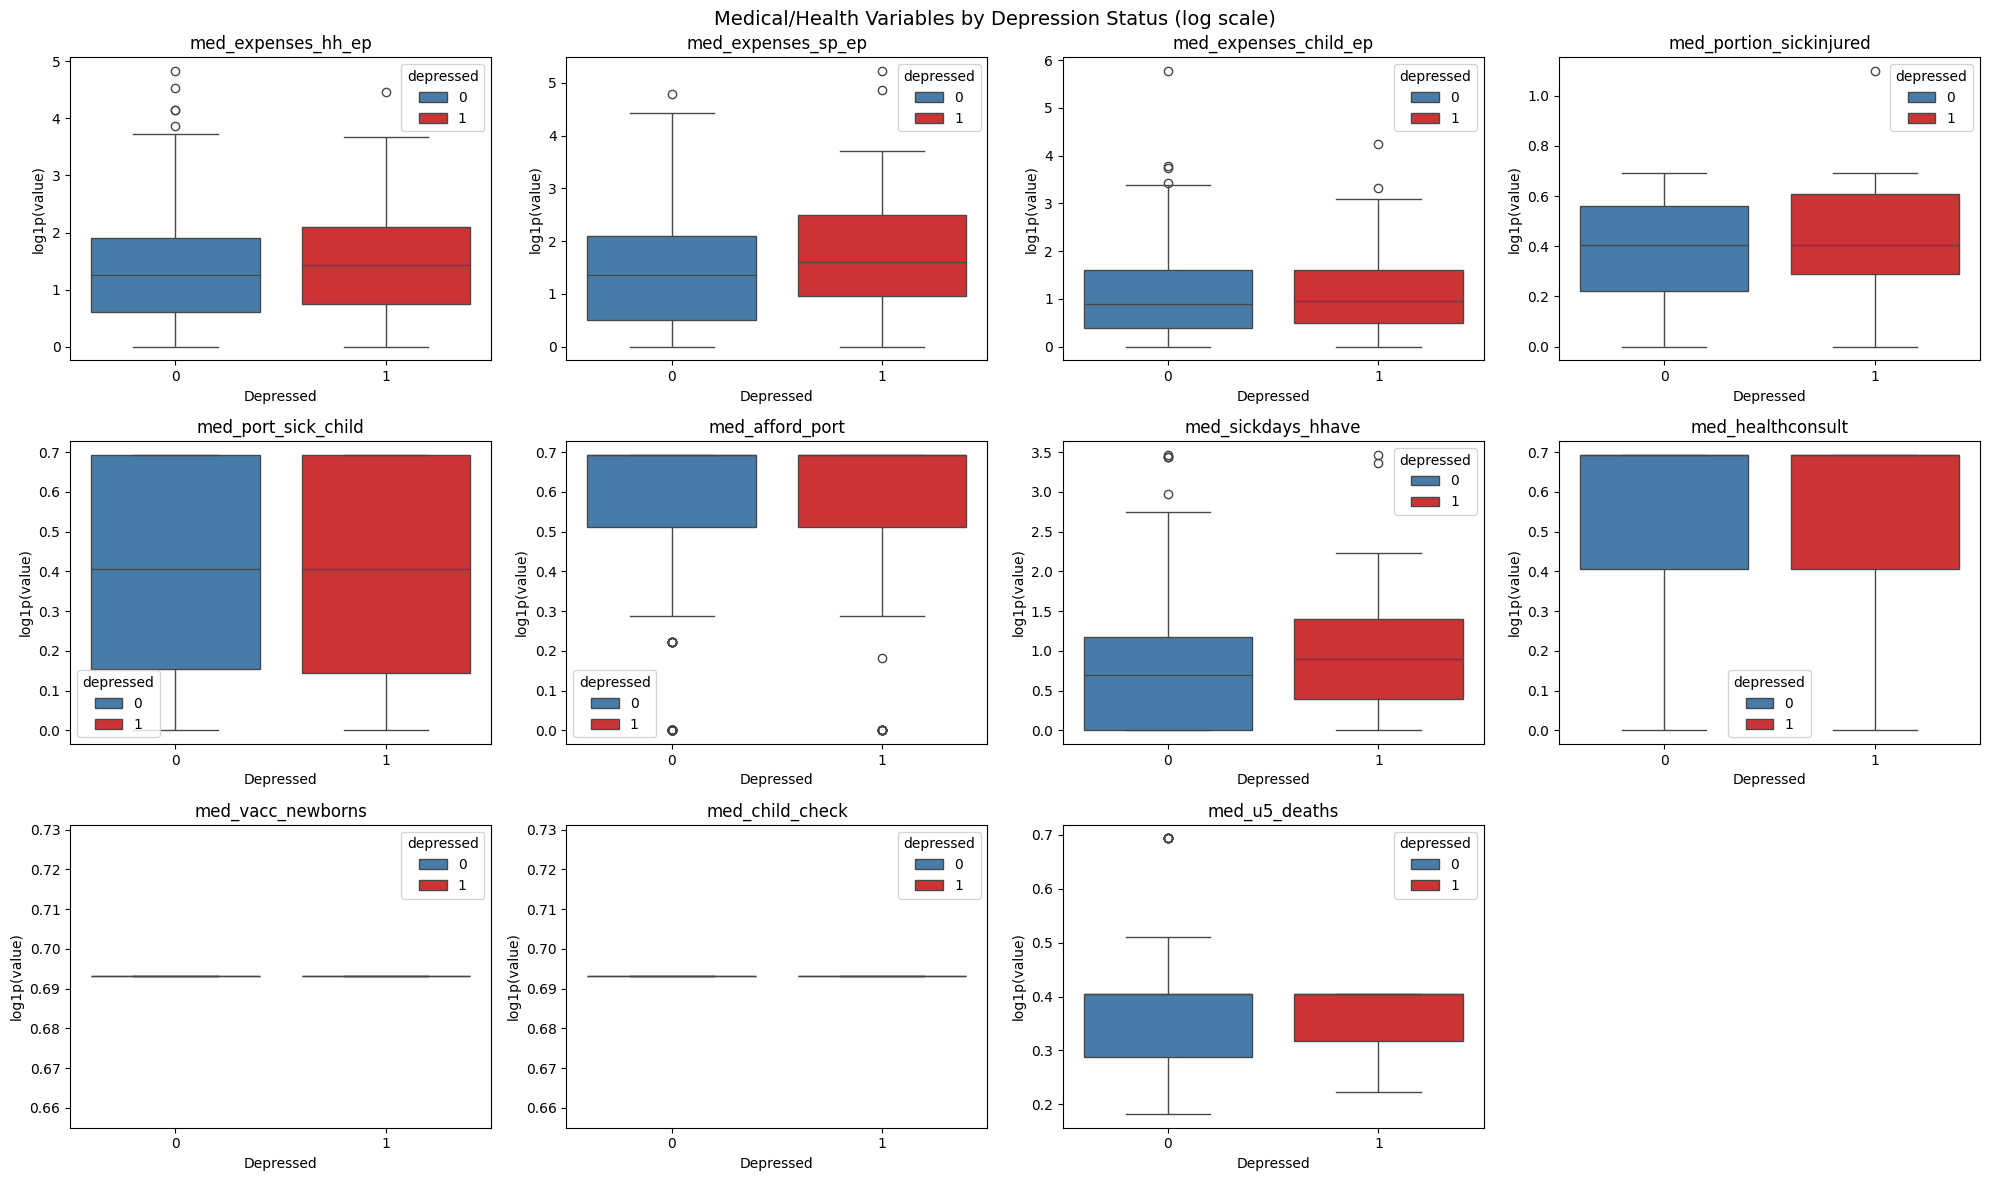

In [26]:
medical_continuous = [v for v in medical_vars if v not in medical_categorical]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(medical_continuous):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")

for j in range(len(medical_continuous), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Medical/Health Variables by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
table_medical = TableOne(
    data,
    columns=medical_vars,
    categorical=medical_categorical,
    groupby="depressed",
    pval=True
)

print(table_medical.tabulate(tablefmt="fancy_grid"))

╒════════════════════════════════════╤════╤═══════════╤════════════╤════════════╤═════════════╤═══════════╕
│                                    │    │   Missing │ Overall    │ 0          │ 1           │   P-Value │
╞════════════════════════════════════╪════╪═══════════╪════════════╪════════════╪═════════════╪═══════════╡
│ n                                  │    │           │ 1143       │ 950        │ 193         │           │
├────────────────────────────────────┼────┼───────────┼────────────┼────────────┼─────────────┼───────────┤
│ med_expenses_hh_ep, mean (SD)      │    │       693 │ 5.6 (10.9) │ 5.4 (10.9) │ 6.5 (11.2)  │     0.416 │
├────────────────────────────────────┼────┼───────────┼────────────┼────────────┼─────────────┼───────────┤
│ med_expenses_sp_ep, mean (SD)      │    │       878 │ 8.1 (17.9) │ 6.9 (12.9) │ 13.1 (31.2) │     0.174 │
├────────────────────────────────────┼────┼───────────┼────────────┼────────────┼─────────────┼───────────┤
│ med_expenses_child_ep, mea

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


**Table 6: Medical/Health Indicators by Depression Status**

Bivariate comparisons of medical and health-related variables by depression status (Table 6) revealed a statistically significant difference in the proportion of household members reported as sick or injured in the past month. Depressed respondents reported a higher mean proportion (0.6, SD 0.3) compared to non-depressed respondents (0.5, SD 0.3; p = 0.049).
No significant differences were observed for medical expenditure per episode for the household overall (p = 0.416), spouses (p = 0.174), or children (p = 0.536), although the spouse medical expenditure showed a notably higher mean among depressed respondents (USD 13.1, SD 31.2) versus non-depressed respondents (USD 6.9, SD 12.9) — a pattern that may warrant attention despite non-significance, given the large relative difference.
The proportion of sick children (p = 0.909), proportion of sick household members who could afford treatment (p = 0.821), average sick days per household member (p = 0.172), and proportion of illnesses where a doctor was consulted (p = 0.191) did not differ significantly between groups. The proportion of under-5 deaths showed a borderline non-significant difference (0.4 vs 0.5, p = 0.065), with depressed respondents reporting a slightly lower mean.
med_vacc_newborns and med_child_check both show a mean and SD of exactly 1.0 (0.0) with no missing values and no p-value computed — indicating these variables are constant across the entire sample (every respondent has the value 1). These are non-informative and should be dropped before modeling.

Several variables in this table have substantial missingness: med_expenses_sp_ep (878 missing, ~77%), med_u5_deaths (1084 missing, ~95%), med_expenses_child_ep (600 missing, ~52%), and med_expenses_hh_ep (693 missing, ~61%). Given missingness exceeding 50-95% for several variables, these should likely be excluded from modeling rather than imputed, as imputation at this scale would introduce more noise than signal; med_u5_deaths in particular, with 95% missing, provides almost no usable information.

The most notable finding in this domain is the significant association between proportion of household members sick/injured and depression status, consistent with the broader pattern of material/health hardship co-occurring with depression observed in earlier tables.

## Education vs Depression status

In [28]:
# Group 6: Education (household-level)
education_vars = [
    "ed_expenses",
    "ed_expenses_perkid",
    "ed_schoolattend",
    "ed_sch_missedpc",
    "ed_work_act_pc"
]

education_categorical = []

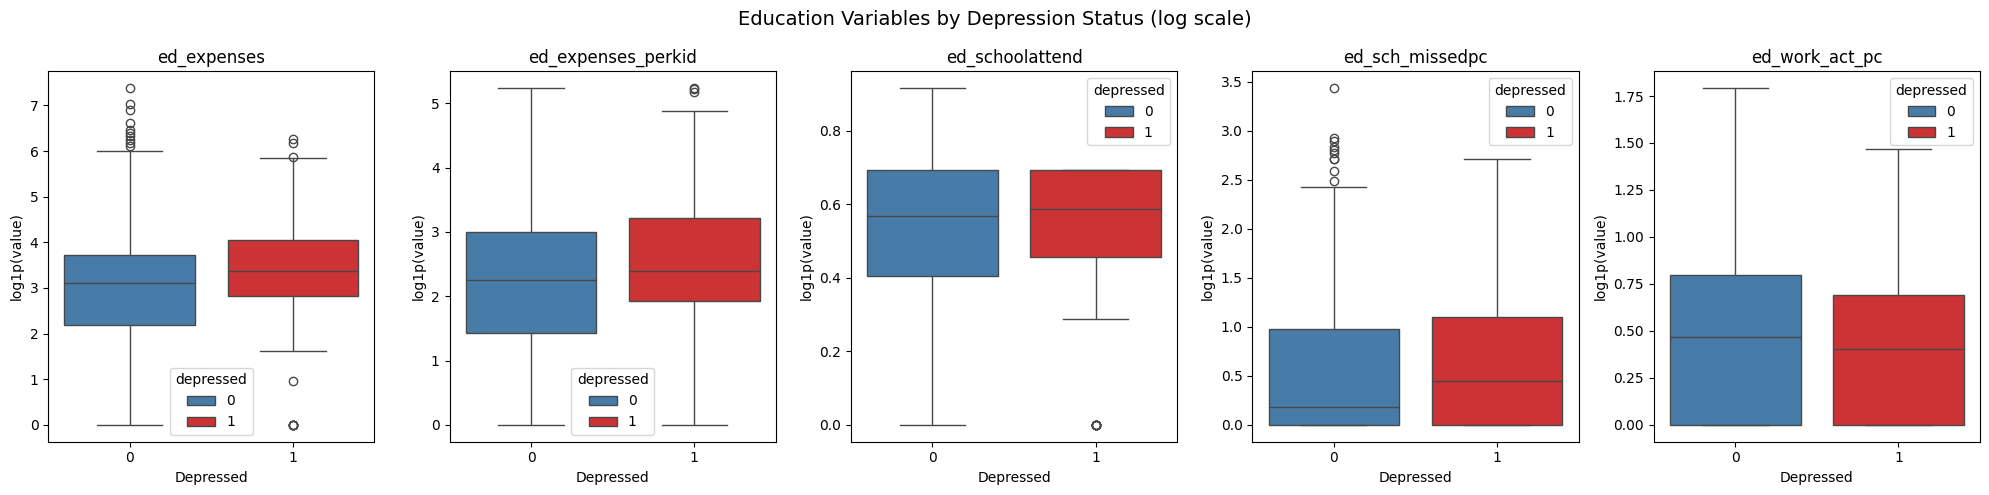

In [29]:
fig, axes = plt.subplots(1, len(education_vars), figsize=(20, 5))

for i, col in enumerate(education_vars):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")

plt.suptitle("Education Variables by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
table_education = TableOne(
    data,
    columns=education_vars,
    categorical=education_categorical,
    groupby="depressed",
    pval=True
)

print(table_education.tabulate(tablefmt="fancy_grid"))

╒═══════════════════════════════╤════╤═══════════╤══════════════╤══════════════╤═════════════╤═══════════╕
│                               │    │   Missing │ Overall      │ 0            │ 1           │   P-Value │
╞═══════════════════════════════╪════╪═══════════╪══════════════╪══════════════╪═════════════╪═══════════╡
│ n                             │    │           │ 1143         │ 950          │ 193         │           │
├───────────────────────────────┼────┼───────────┼──────────────┼──────────────┼─────────────┼───────────┤
│ ed_expenses, mean (SD)        │    │       463 │ 52.9 (117.3) │ 51.6 (121.4) │ 59.8 (92.8) │     0.425 │
├───────────────────────────────┼────┼───────────┼──────────────┼──────────────┼─────────────┼───────────┤
│ ed_expenses_perkid, mean (SD) │    │       463 │ 18.6 (31.6)  │ 17.7 (30.7)  │ 23.2 (35.6) │     0.132 │
├───────────────────────────────┼────┼───────────┼──────────────┼──────────────┼─────────────┼───────────┤
│ ed_schoolattend, mean (SD)    │    

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


**Table 7: Education-Related Household Indicators by Depression Status**

Bivariate comparisons of education-related variables by depression status (Table 7) revealed no statistically significant differences between groups for any of the variables examined.

Mean education expenditure was higher among depressed respondents (USD 59.8, SD 92.8) compared to non-depressed respondents (USD 51.6, SD 121.4), though this difference was not significant (p = 0.425). Similarly, education expenditure per child showed a higher mean among depressed respondents (USD 23.2, SD 35.6) versus non-depressed respondents (USD 17.7, SD 30.7), but this difference also did not reach significance (p = 0.132).

The proportion of school-aged children currently in school showed a borderline non-significant difference (p = 0.092), with no meaningful difference in mean values (0.7 in both groups). School days missed per child (p = 0.506) and income-generating activities per school-aged child (p = 0.154) did not differ significantly between groups, though the latter showed a directionally lower mean among depressed respondents (0.6 vs 0.8), potentially consistent with reduced household economic activity observed in earlier tables.

All five variables in this group share an identical missingness pattern of 463-571 missing observations (approximately 40-50% of the sample), suggesting these may originate from a single survey module administered only to a subset of households (e.g., households with school-aged children). This should be verified, as the missingness here is likely **structural** (not applicable to childless households) rather than random, and should be handled differently from random missingness — for example, by creating a "has school-aged children" indicator alongside these variables, or by restricting analysis of this domain to the relevant subpopulation.

Overall, no education-related variable showed a statistically significant univariate association with depression status in this sample, though the directional trends (higher education expenditure, fewer income-generating activities per child among depressed respondents) are broadly consistent with the economic hardship pattern observed elsewhere.


## Mpesa Us

In [31]:
# Group 7: M-Pesa / Mobile Money
mpesa_vars = [
    "given_mpesa",
    "amount_given_mpesa",
    "received_mpesa",
    "amount_received_mpesa",
    "net_mpesa",
    "saved_mpesa",
    "amount_saved_mpesa"
]

mpesa_categorical = [
    "given_mpesa",
    "received_mpesa",
    "saved_mpesa"
]

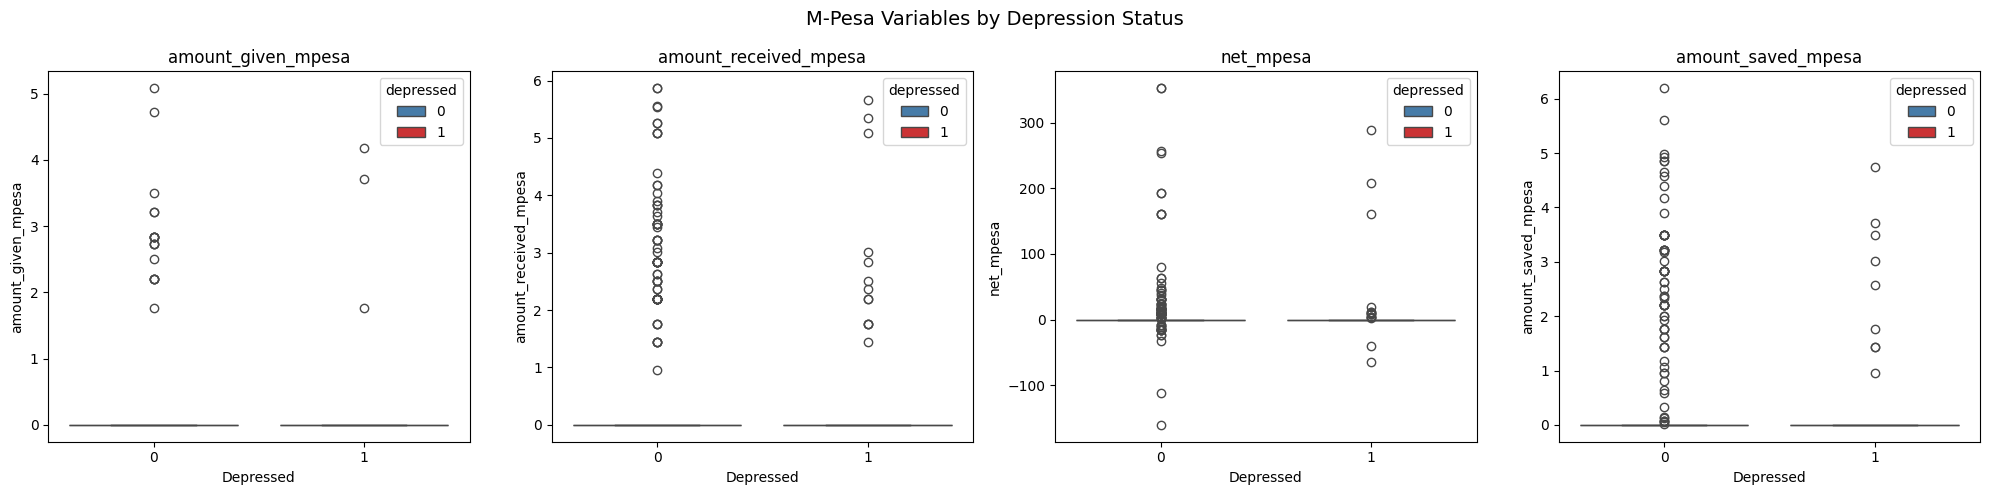

In [32]:
# Boxplots for continuous M-Pesa variables
mpesa_continuous = [v for v in mpesa_vars if v not in mpesa_categorical]

fig, axes = plt.subplots(1, len(mpesa_continuous), figsize=(20, 5))

for i, col in enumerate(mpesa_continuous):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)) if data[col].min() >= -1 else data[col],
                ax=axes[i], hue="depressed", palette=color_mapping)
    axes[i].set_title(col)
    axes[i].set_xlabel("Depressed")

plt.suptitle("M-Pesa Variables by Depression Status", fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
table_mpesa = TableOne(
    data,
    columns=mpesa_vars,
    categorical=mpesa_categorical,
    groupby="depressed",
    pval=True
)

print(table_mpesa.tabulate(tablefmt="fancy_grid"))

╒══════════════════════════════════╤════╤═══════════╤═════════════╤════════════╤════════════╤═══════════╕
│                                  │    │   Missing │ Overall     │ 0          │ 1          │   P-Value │
╞══════════════════════════════════╪════╪═══════════╪═════════════╪════════════╪════════════╪═══════════╡
│ n                                │    │           │ 1143        │ 950        │ 193        │           │
├──────────────────────────────────┼────┼───────────┼─────────────┼────────────┼────────────┼───────────┤
│ given_mpesa, n (%)               │  0 │           │ 1125 (98.4) │ 934 (98.3) │ 191 (99.0) │     0.753 │
├──────────────────────────────────┼────┼───────────┼─────────────┼────────────┼────────────┼───────────┤
│                                  │  1 │           │ 18 (1.6)    │ 16 (1.7)   │ 2 (1.0)    │           │
├──────────────────────────────────┼────┼───────────┼─────────────┼────────────┼────────────┼───────────┤
│ amount_given_mpesa, mean (SD)    │    │     

c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tableone\formatting.py:177: UserWarning: Order variable not found: age_group
  warnings.warn(f"Order variable not found: {k}")


**Table 8: Mobile Money (M-Pesa) Usage by Depression Status**

Bivariate comparisons of M-Pesa usage and transaction variables by depression status (Table 8) revealed no statistically significant differences between groups for any of the variables examined.

The proportion of respondents who sent money via M-Pesa was similar between depressed (1.0%) and non-depressed respondents (1.7%; p = 0.753), with no significant difference in the mean amount sent (p = 0.977). Likewise, the proportion who received money via M-Pesa did not differ significantly between groups (6.2% vs 6.7%, p = 0.916), nor did the mean amount received (USD 3.9 vs USD 3.5, p = 0.867) or net M-Pesa remittances (USD 3.3 vs USD 3.0, p = 0.874).

The proportion of respondents who saved money via M-Pesa was similar across groups (17.6% vs 19.2%, p = 0.691). The mean amount saved was lower among depressed respondents (USD 1.2, SD 9.1) compared to non-depressed respondents (USD 2.5, SD 21.2), though this difference was not significant (p = 0.172).

All M-Pesa variables in this table show very low usage rates overall (1.6% sent, 6.6% received, 18.9% saved), indicating that mobile money transactions/savings are relatively uncommon behaviors in this sample, which may limit the statistical power to detect associations even if true effects exist. No M-Pesa-related variable showed a statistically significant univariate association with depression status.

---

**Summary across Tables 2-8: Bivariate EDA**

Across all variable groups examined, only a small number of variables showed statistically significant univariate associations with depression status (p < 0.05): `asset_durable`, `nondurable_investment` (Table 2), `ent_nonag_flowcost`, `ent_total_cost` (Table 4), `fs_adwholed_often` (Table 5), and `med_portion_sickinjured` (Table 6). The recurring theme across these is **reduced economic activity/investment combined with greater material hardship (food deprivation, sickness)** among depressed respondents — though given the large number of comparisons performed, some of these associations may reflect chance.

Several variables were identified as constant or near-constant (`asset_niceroof`, `med_vacc_newborns`, `med_child_check`) and should be dropped prior to modeling. Variables with very high missingness (`med_u5_deaths`, `med_expenses_sp_ep`, and others exceeding ~50%) should also be excluded or handled separately given the limited information they carry.

This much weaker set of univariate signals (relative to the strength typically needed for standalone clinical screening) reinforces the rationale for a **multivariate ML approach with SHAP-based interpretation**, which can capture combinations and interactions of features that individual bivariate tests cannot detect.

## Check missing data

In [34]:
def report_missing_data(data_frame: pd.DataFrame) -> pd.DataFrame:
    """Analyze a DataFrame and return a summary table of missing values.

    This function calculates the absolute count and percentage of missing
    values for each column in the input DataFrame. It filters out columns
    with zero missing data and sorts the results in descending order.

    Parameters
    ----------
    data_frame : pd.DataFrame
        The pandas DataFrame to inspect for missing values.

    Returns
    -------
    pd.DataFrame
        A DataFrame indexed by column names with two metrics:
        - 'Missing Values': Total count of null cells.
        - 'Percentage (%)': Percentage of null cells relative to total rows.
    """
    # Calculate absolute count of missing values
    missing_count = data_frame.isnull().sum()

    # Calculate percentage of missing values based on total row count
    missing_percent = (missing_count / len(data_frame)) * 100

    # Combine metrics side-by-side into a single report table
    missing_table = pd.concat([missing_count, missing_percent], axis=1)
    missing_table.columns = ["Missing Values", "Percentage (%)"]

    # Filter out columns with no missing data
    filtered_table = missing_table[missing_table["Missing Values"] > 0]

    # Sort the table so the worst offending columns appear at the top
    return filtered_table.sort_values(by="Missing Values", ascending=False)

In [35]:
data_missing_report = report_missing_data(data)
print(data_missing_report)

                         Missing Values  Percentage (%)
med_u5_deaths                      1084       94.838145
med_expenses_sp_ep                  878       76.815398
med_expenses_hh_ep                  693       60.629921
med_expenses_child_ep               600       52.493438
ed_work_act_pc                      571       49.956255
ed_sch_missedpc                     467       40.857393
ed_expenses                         463       40.507437
ed_expenses_perkid                  463       40.507437
ed_schoolattend                     463       40.507437
med_healthconsult                   423       37.007874
med_afford_port                     423       37.007874
cons_med_children                   419       36.657918
fs_chskipm_often                    416       36.395451
fs_chwholed_often                   416       36.395451
med_port_sick_child                 416       36.395451
med_portion_sickinjured             334       29.221347
fs_enoughtom                        334       29

# Data Preporcessing for the Model building process

1. Drop non-informative variables - surveyid, village, survey_date (done)
2. Drop constant variables identified in EDA (asset_niceroof, med_vacc_newborns, med_child_check)
3. Drop variables with >30% missing
4. Encode categorical/dummy variables
5. Impute remaining missing data using MICE
6. Check multicollinearity - drop features with correlation > 0.8
7. Tabulate final preprocessing table
8. Balance y variable classes using SMOTE-ENN (TRAIN SET ONLY)

## Final Processing steps


### Drop Constant variables

These are variables that were identified as constant during the EDA process

In [36]:
constant_vars = ["asset_niceroof", "med_vacc_newborns", "med_child_check"]

# confirm is there actually constant variables in the dataset
for col in constant_vars:
    if col in data.columns:
        print(col, "-> unique values:", data[col].nunique())

dropped_constant = [c for c in constant_vars if c in data.columns]
data.drop(columns=dropped_constant, inplace=True, errors='ignore')

tracker.log_exclusion("Constant variables", len(dropped_constant))
print(f"Dropped {len(dropped_constant)} constant variables: {dropped_constant}")

asset_niceroof -> unique values: 2
med_vacc_newborns -> unique values: 1
med_child_check -> unique values: 1
Dropped 3 constant variables: ['asset_niceroof', 'med_vacc_newborns', 'med_child_check']


We also drop redundant age group column

In [37]:
# Drop age_group (derived from age, redundant)
data.drop(columns=["age_group"], inplace=True, errors='ignore')

tracker.log_exclusion("Redundant derived variable (age_group)", 1)

print(data.shape)

(1143, 68)


### Handling Missing Data

The process includes dropping columns with missing > 30%. The second part will include imputing missing data using MICE

**Part 1: Dropping variable with >30% missing**

In [38]:
# Drop variables with more than 30% missing data
missing_threshold = 30  # percent

missing_pct = (data.isnull().sum() / len(data)) * 100
cols_above_threshold = missing_pct[missing_pct > missing_threshold].index.tolist()

dropped_high_missing = cols_above_threshold
data.drop(columns=dropped_high_missing, inplace=True, errors='ignore')

tracker.log_exclusion("Above 30% missing", len(dropped_high_missing))
print(f"Dropped {len(dropped_high_missing)} variables with >30% missing:")
print(dropped_high_missing)

Dropped 15 variables with >30% missing:
['cons_med_children', 'fs_chskipm_often', 'fs_chwholed_often', 'med_expenses_hh_ep', 'med_expenses_sp_ep', 'med_expenses_child_ep', 'med_port_sick_child', 'med_afford_port', 'med_healthconsult', 'med_u5_deaths', 'ed_expenses', 'ed_expenses_perkid', 'ed_schoolattend', 'ed_sch_missedpc', 'ed_work_act_pc']


In [39]:
# check pre-procssinglog table
tracker.generate_table()

,Count
Pre-processing step,
Total available variables,75
"Survey identifiers (id, village, date, day_of_week)",4
Constant variables,3
Redundant derived variable (age_group),1
Above 30% missing,15
Total excluded,23
Final variables,52


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   femaleres                1143 non-null   int64  
 1   age                      1143 non-null   float64
 2   married                  1143 non-null   int64  
 3   children                 1143 non-null   int64  
 4   hhsize                   1143 non-null   int64  
 5   edu                      1143 non-null   int64  
 6   hh_children              1143 non-null   int64  
 7   hh_totalmembers          809 non-null    float64
 8   cons_nondurable          1143 non-null   float64
 9   asset_livestock          1143 non-null   float64
 10  asset_durable            1143 non-null   float64
 11  asset_phone              1143 non-null   float64
 12  asset_savings            1143 non-null   float64
 13  asset_land_owned_total   1143 non-null   float64
 14  cons_allfood            

Since all variables are numeric in nature, there is not need to encode any variables

In [41]:
tracker.log_exclusion("Categorical encoding (none required)", 0)

**Missing Data Imputation (MICE)**

Following the removal of constant and high-missingness (>30%) variables, eight remaining variables retained missing values below the 30% threshold (ranging from 1.7% to 29.2%): `hh_totalmembers`, `fs_meat`, `fs_sleephun`, `fs_enoughtom`, `med_portion_sickinjured`, `med_sickdays_hhave`, `cons_alcohol`, and `cons_tobacco`.



In [42]:
# check columns that are missing
data_missing_report = report_missing_data(data)
print(data_missing_report)

                         Missing Values  Percentage (%)
hh_totalmembers                     334       29.221347
fs_meat                             334       29.221347
fs_sleephun                         334       29.221347
fs_enoughtom                        334       29.221347
med_portion_sickinjured             334       29.221347
med_sickdays_hhave                  334       29.221347
cons_alcohol                         43        3.762030
cons_tobacco                         20        1.749781


Multiple Imputation by Chained Equations (MICE), implemented via scikit-learn's `IterativeImputer`, was applied to estimate these missing values using the relationships among all remaining numeric features. MICE was selected over simple imputation methods (e.g., mean/median) as it accounts for inter-variable correlations, producing more plausible imputed values conditional on each respondent's broader survey responses.

In [43]:
# Variables to impute via MICE, grouped by type and constraints
mice_vars = [
    "hh_totalmembers",
    "fs_meat",
    "fs_sleephun",
    "fs_enoughtom",
    "med_portion_sickinjured",
    "med_sickdays_hhave",
    "cons_alcohol",
    "cons_tobacco"
]

# Variables that must be rounded to integers after imputation
integer_vars = ["hh_totalmembers", "fs_meat"]

# Binary variables (round to nearest 0/1, clip to [0,1])
binary_vars = ["fs_sleephun", "fs_enoughtom"]

# Proportion variables (clip to [0,1])
proportion_vars = ["med_portion_sickinjured"]

# Bounded count variables (clip to [0, upper_bound])
bounded_vars = {
    "med_sickdays_hhave": (0, 30),   # days in a month
    "fs_meat": (0, 7),               # times last week
    "hh_totalmembers": (1, None)     # at least 1 person, no realistic upper cap
}

In [44]:
# now run MICE imputation 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# fit MICE on the full feature set, (excluding target) for better imputation context
feature_cols = [c for c in data.columns if c != "depressed"]

imputer = IterativeImputer(max_iter=10, random_state=42, sample_posterior=True)
imputed_array = imputer.fit_transform(data[feature_cols])

imputed_df = pd.DataFrame(imputed_array, columns=feature_cols, index = data.index)

# replace inly the columns taht had missing values; leave others unchanged
# this helps to avoind tiny flaotingg-point drify on already-complete numeric columns
for col in mice_vars:
    data[col] = imputed_df[col]

Following imputation, post-processing constraints were applied based on each variable's definition and plausible range, in order to ensure imputed values remained realistic:

- **Integer counts** (`hh_totalmembers`, `fs_meat`) were rounded to whole numbers.
- **Binary indicators** (`fs_sleephun`, `fs_enoughtom`) were rounded and clipped to {0, 1}.
- **Proportions** (`med_portion_sickinjured`) were clipped to the [0, 1] range.
- **Bounded counts** were constrained to their logical maxima: `med_sickdays_hhave` to [0, 30] (days in a month) and `fs_meat` to [0, 7] (occurrences in the past week); `hh_totalmembers` was constrained to a minimum of 1.
- **Continuous expenditure variables** (`cons_alcohol`, `cons_tobacco`) were clipped to non-negative values only.

No variables were dropped at this stage; the dataset retains its full set of columns

In [45]:
# apply post-imputation corrections based on variable definitions
import numpy as np

# 1. Round integer-valued variables
for col in integer_vars:
    data[col] = data[col].round().astype(int)

# 2. Round and clip binary variables to {0, 1}
for col in binary_vars:
    data[col] = data[col].round().clip(0, 1).astype(int)

# 3. Clip proportion variables to [0, 1]
for col in proportion_vars:
    data[col] = data[col].clip(0, 1)

# 4. Apply bounded ranges (after rounding, where applicable)
for col, (lower, upper) in bounded_vars.items():
    if upper is not None:
        data[col] = data[col].clip(lower, upper)
    else:
        data[col] = data[col].clip(lower=lower)

# cons_alcohol, cons_tobacco are continuous USD values - clip negatives only
for col in ["cons_alcohol", "cons_tobacco"]:
    data[col] = data[col].clip(lower=0)

print(data[mice_vars].describe())
print("\nRemaining missing values:", data[mice_vars].isnull().sum().sum())

       hh_totalmembers      fs_meat  fs_sleephun  fs_enoughtom  \
count      1143.000000  1143.000000  1143.000000   1143.000000   
mean          4.872266     2.958880     0.377953      0.258968   
std           2.144792     1.984852     0.485088      0.438260   
min           1.000000     0.000000     0.000000      0.000000   
25%           3.000000     2.000000     0.000000      0.000000   
50%           5.000000     3.000000     0.000000      0.000000   
75%           6.000000     4.000000     1.000000      1.000000   
max          12.000000     7.000000     1.000000      1.000000   

       med_portion_sickinjured  med_sickdays_hhave  cons_alcohol  cons_tobacco  
count              1143.000000         1143.000000   1143.000000   1143.000000  
mean                  0.504461            1.998050      1.149994      0.624300  
std                   0.305730            3.108408      6.614847      2.723160  
min                   0.000000            0.000000      0.000000      0.000000  


In [46]:
# check missing values after MICE imputation
data_missing_report = report_missing_data(data)
print(data_missing_report)

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [47]:
# log into tracker
# MICE doesn't drop variables, but log the step for completeness
tracker.log_exclusion("MICE imputation (no variables dropped)", 0)

### Data Preprocessing: Multicollinearity Assessment

Multicollinearity occurs when two or more predictor variables are highly linearly correlated, meaning they carry largely redundant information. While tree-based ensemble methods (Random Forest, XGBoost, LightGBM) are relatively robust to multicollinearity in terms of predictive accuracy, highly correlated features can still distort model interpretability — particularly for SHAP-based feature importance, where explanatory "credit" may be split inconsistently between correlated features — and can inflate coefficient variance in linear models such as Logistic Regression, making coefficients unstable and difficult to interpret.

Given the breadth of classifiers under consideration in this analysis (Logistic Regression, Random Forest, XGBoost, LightGBM, SVM, and KNN), addressing multicollinearity at the preprocessing stage ensures a consistent feature set across all models and supports more reliable interpretation of feature importance regardless of the final model selected.

A pairwise Pearson correlation matrix was computed across all numeric features. Feature pairs with an absolute correlation coefficient exceeding **0.8** were flagged as highly collinear. This threshold was selected as a conservative cutoff commonly applied in applied machine learning workflows, balancing the removal of genuinely redundant features against the preservation of feature richness for downstream modeling. For each flagged pair, the feature with the weaker association with the target variable (`depressed`) was dropped, retaining the more predictive of the two correlated variables.

In [48]:
# Compute correlation matrix and identify high-correlation pairs

# pairwise correlation matrix for all features (excluding target)
feaure_cols = [c for c in data.columns if c != "depressed"]
corr_matrix = data[feature_cols].corr().abs()

# get upper triangle  of the correlation matrix (avoid duplicate pairs and self-correlation
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
)

# find feature pairs with correlation above threshold
threshold = 0.8
high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["correlation"] > threshold]
high_corr_pairs = high_corr_pairs.sort_values("correlation", ascending=False)

print(high_corr_pairs)

                  feature_1           feature_2  correlation
1053     ent_nonag_flowcost      ent_total_cost     0.997000
200                  hhsize     hh_totalmembers     0.993998
1316  amount_received_mpesa           net_mpesa     0.967959
385         cons_nondurable        cons_allfood     0.966560
150                children              hhsize     0.934689
153                children     hh_totalmembers     0.926111
908           ent_wagelabor       labor_primary     0.897600
455         asset_livestock  durable_investment     0.811470


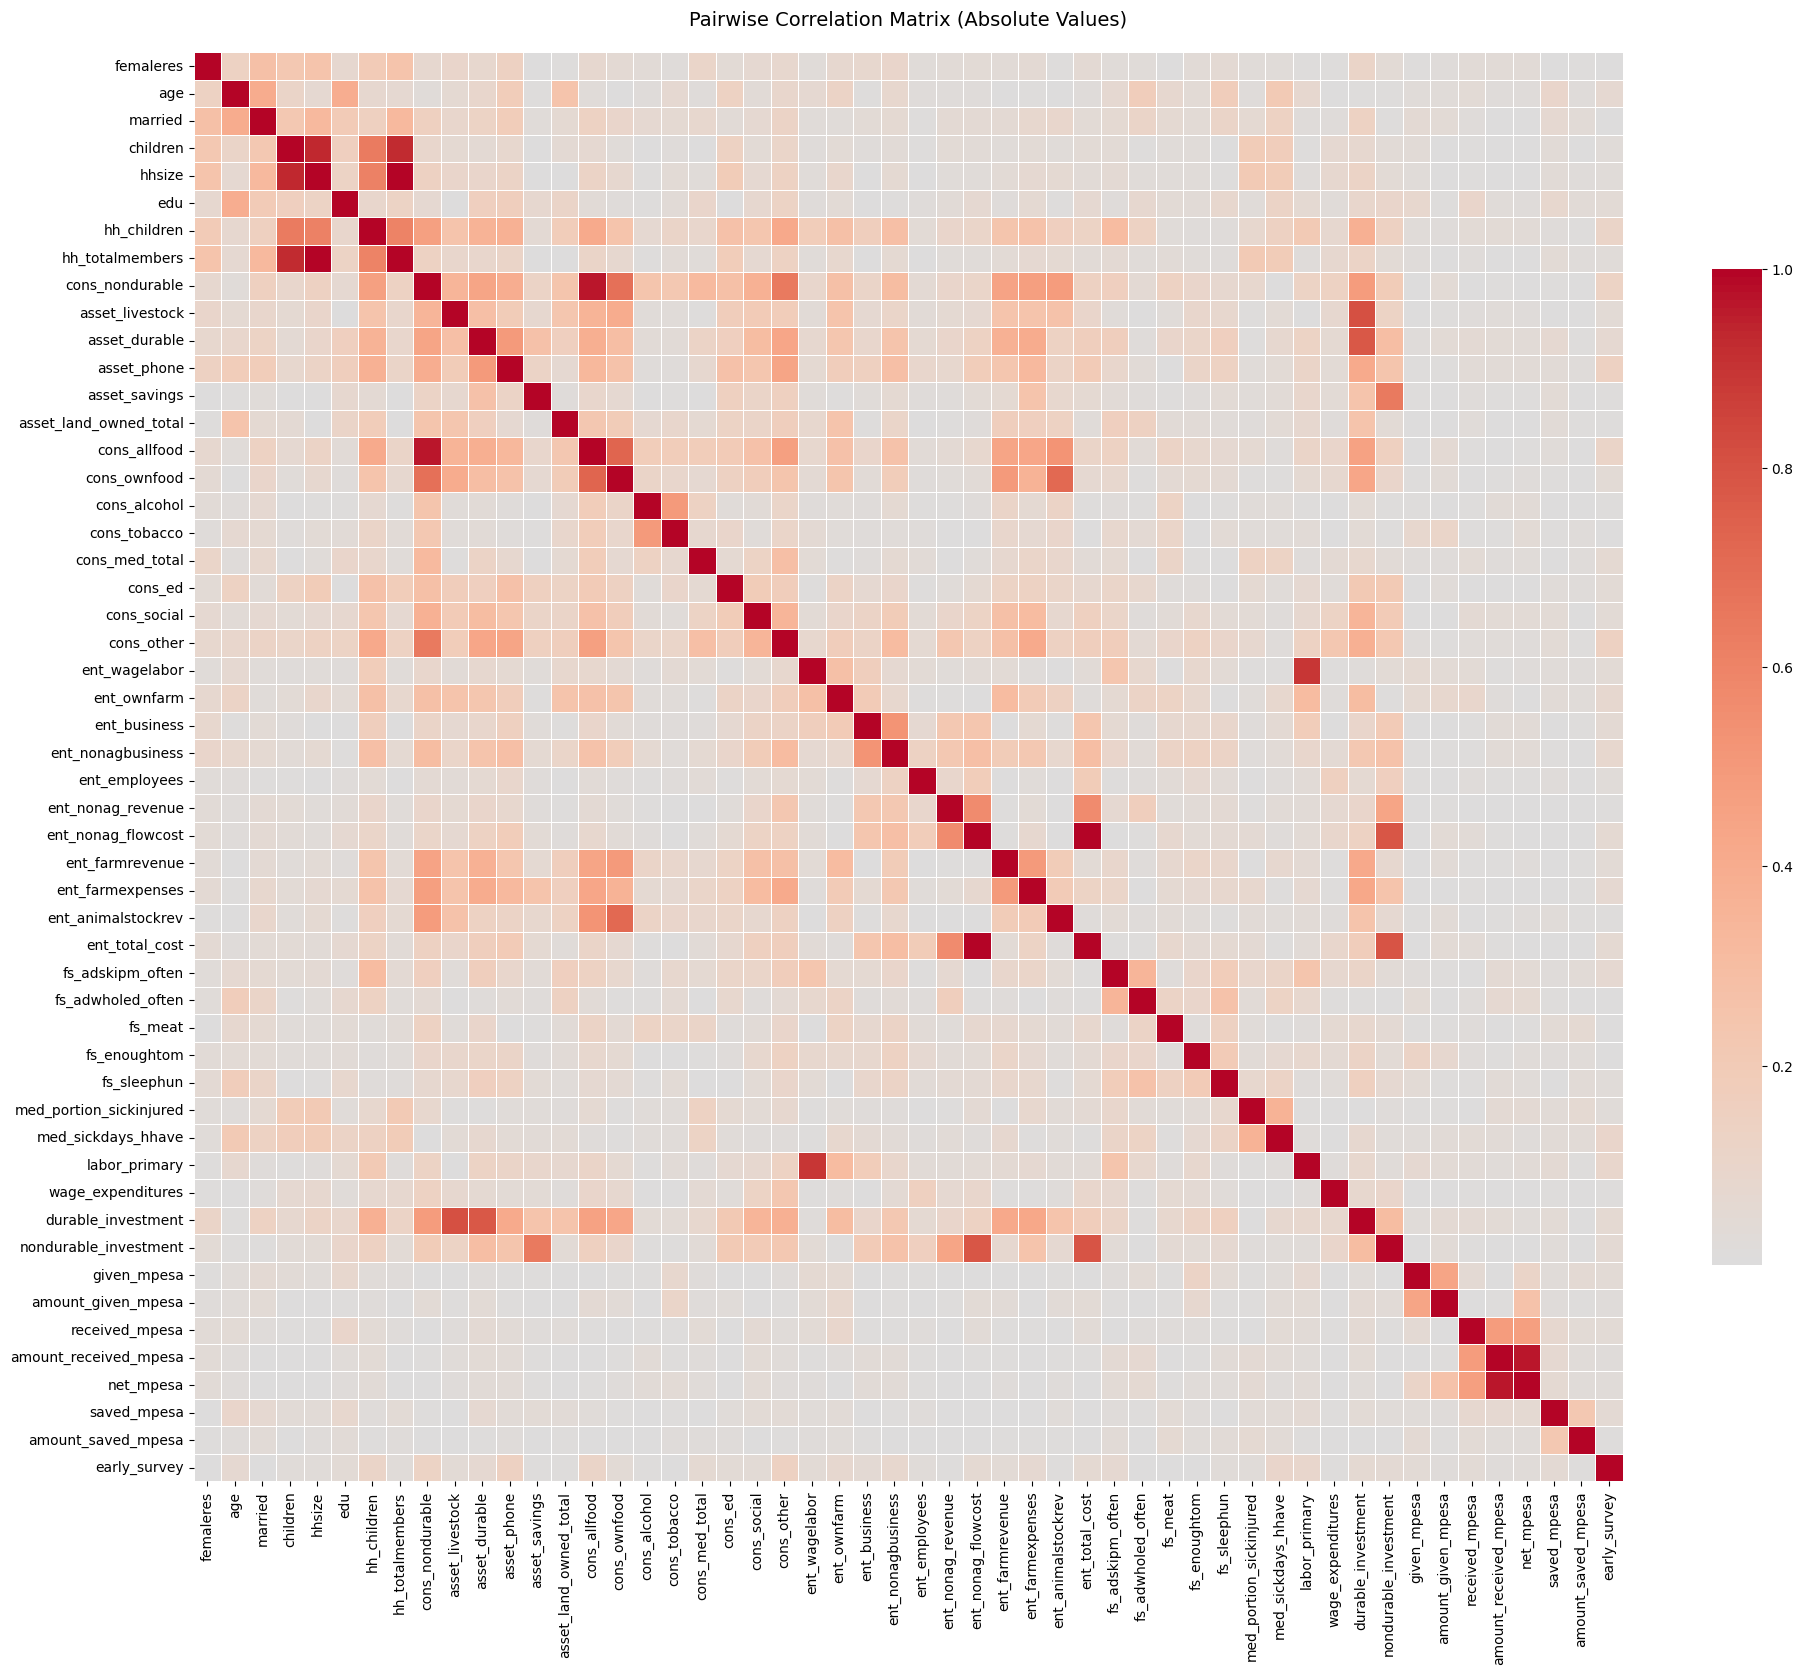

In [49]:
fig, ax = plt.subplots(figsize=(20, 18))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    ax=ax
)

ax.set_title("Pairwise Correlation Matrix (Absolute Values)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

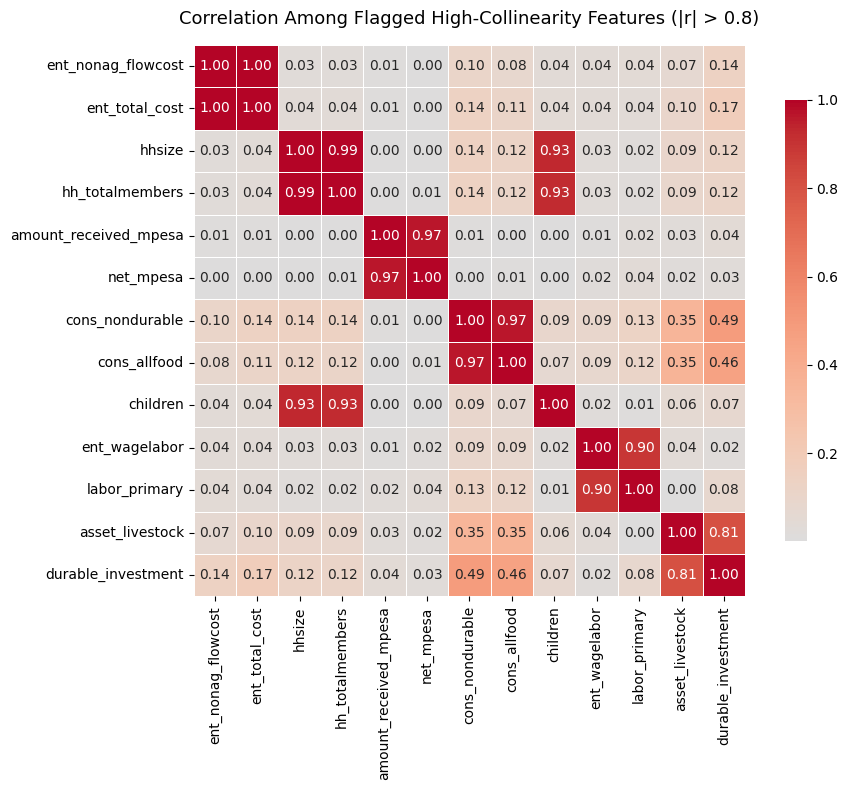

In [50]:
# correlation plot for highly correlated features
# Get unique features involved in any high-correlation pair
flagged_features = pd.unique(
    high_corr_pairs[["feature_1", "feature_2"]].values.ravel()
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix.loc[flagged_features, flagged_features],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation Among Flagged High-Collinearity Features (|r| > 0.8)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [51]:
# Determine which features to drop from each pair (weaker target correlation)

# correlation of each feature with the target
target_corr = data[feature_cols].corrwith(data["depressed"]).abs()

to_drop = set()

for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]

    # if either feature was already marked for dropping, skip re-evaluating
    if f1 in to_drop or f2 in to_drop:
        continue

    # drop whichever has weaker correlation with the target
    if target_corr[f1] >= target_corr[f2]:
        to_drop.add(f2)
    else:
        to_drop.add(f1)

to_drop = list(to_drop)
print(f"Features to drop ({len(to_drop)}):")
for f in to_drop:
    print(f"  {f}  (target corr: {target_corr[f]:.3f})")

Features to drop (7):
  hh_totalmembers  (target corr: 0.002)
  ent_wagelabor  (target corr: 0.000)
  durable_investment  (target corr: 0.016)
  ent_nonag_flowcost  (target corr: 0.036)
  hhsize  (target corr: 0.006)
  cons_nondurable  (target corr: 0.021)
  net_mpesa  (target corr: 0.005)


In [52]:
# dropping the identified highly correlated features and log the step
data.drop(columns=to_drop, inplace=True, errors='ignore')

tracker.log_exclusion("Above 0.8 correlated features", len(to_drop))

print(data.shape)

(1143, 46)


In [53]:
# check table log
tracker.generate_table()

,Count
Pre-processing step,
Total available variables,75
"Survey identifiers (id, village, date, day_of_week)",4
Constant variables,3
Redundant derived variable (age_group),1
Above 30% missing,15
Categorical encoding (none required),0
MICE imputation (no variables dropped),0
Above 0.8 correlated features,7
Total excluded,30


### Addressing Class Imbalance: SMOTE-ENN

As identified during the initial exploratory analysis, the target variable `depressed` is substantially imbalanced, with depressed respondents (n = 193, 16.9%) representing a minority relative to non-depressed respondents (n = 950, 83.1%). Left unaddressed, this imbalance can bias classifiers toward the majority class, resulting in poor sensitivity (recall) for identifying depressed individuals — the outcome of greatest practical importance in this context.

While class weighting (assigning higher misclassification penalties to the minority class) is a common and computationally simpler approach, this analysis instead employs **SMOTE-ENN** (Synthetic Minority Over-sampling Technique combined with Edited Nearest Neighbours), a hybrid resampling technique applied directly to the training data.

SMOTE-ENN operates in two stages:

1. **SMOTE** generates synthetic samples for the minority class (`depressed = 1`) by interpolating between existing minority-class observations and their nearest neighbours, addressing the class imbalance through oversampling.
2. **Edited Nearest Neighbours (ENN)** subsequently removes observations (from either class) whose class label disagrees with the majority label of their nearest neighbours. This cleaning step reduces noise and ambiguous/overlapping samples that SMOTE's interpolation can introduce, particularly near class boundaries.

This combined approach was selected over plain SMOTE or class weighting because it not only rebalances the class distribution but also actively removes noisy or borderline synthetic and original samples, potentially yielding cleaner decision boundaries for the classifiers under consideration.

**Important**: SMOTE-ENN is applied **only to the training set, after the train/validation split**, to avoid data leakage. The validation and test sets retain their original (imbalanced) class distribution, reflecting real-world deployment conditions.

In [54]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler

# Step 1: Split your full labeled data BEFORE any resampling
X = data.drop(columns=["depressed"])
y = data["depressed"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "| Val shape:", X_val.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nVal class distribution:\n", y_val.value_counts(normalize=True))

Train shape: (914, 45) | Val shape: (229, 45)

Train class distribution:
 depressed
0    0.83151
1    0.16849
Name: proportion, dtype: float64

Val class distribution:
 depressed
0    0.829694
1    0.170306
Name: proportion, dtype: float64


In [55]:
# SMOTE-ENN on training data only
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

print("Resampled training shape:", X_train_resampled.shape)
print(y_train_resampled.value_counts())

Resampled training shape: (946, 45)
depressed
1    625
0    321
Name: count, dtype: int64


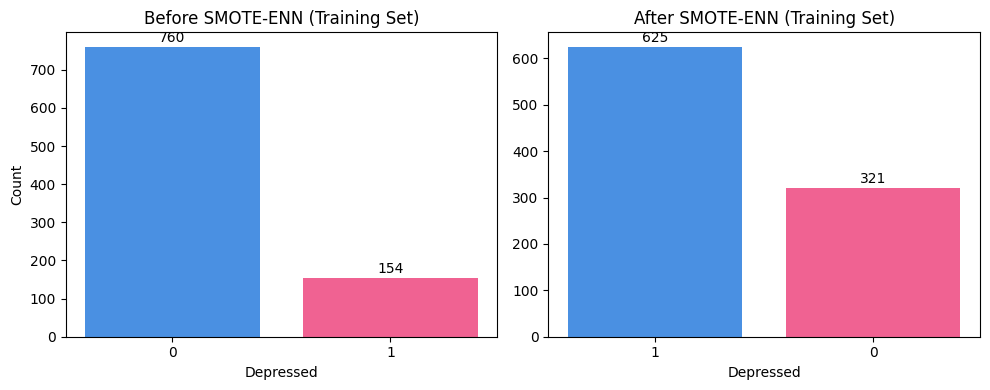

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE-ENN
before_counts = y_train.value_counts()
bars1 = axes[0].bar(before_counts.index.astype(str), before_counts.values, color=["#4A90E2", "#F06292"])
axes[0].set_title("Before SMOTE-ENN (Training Set)")
axes[0].set_xlabel("Depressed")
axes[0].set_ylabel("Count")

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}',
                  ha='center', va='bottom', fontsize=10)

# After SMOTE-ENN
after_counts = y_train_resampled.value_counts()
bars2 = axes[1].bar(after_counts.index.astype(str), after_counts.values, color=["#4A90E2", "#F06292"])
axes[1].set_title("After SMOTE-ENN (Training Set)")
axes[1].set_xlabel("Depressed")

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}',
                  ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Feature Scaling

Following class balancing, all features were standardized using `StandardScaler` (zero mean, unit variance). The scaler was fit on the resampled training data and applied to the validation set using the same fitted parameters, consistent with the principle of avoiding data leakage. Standardization is required for distance-based and gradient-based classifiers (Logistic Regression, SVM, KNN) under consideration, while tree-based ensembles (Random Forest, XGBoost, LightGBM) are scale-invariant and unaffected by this transformation.

In [57]:
# Step 3: Scale - fit on resampled training, transform train and val
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_resampled.columns, index=X_train_resampled.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

# Model Building: Algorithm Selection via Randomized Hyperparameter Search and Cross-Validation

Seven classification algorithms were evaluated for predicting depression status: Logistic Regression, Elastic Net-regularized Logistic Regression, Random Forest, Support Vector Machine (SVM), k-Nearest Neighbors (KNN), Extreme Gradient Boosting (XGBoost), and Light Gradient Boosting Machine (LightGBM).

For each algorithm, a randomized search over **8 hyperparameter configurations** was conducted, drawn from a predefined distribution of plausible values for that model. This search size was selected to balance methodological rigor with computational feasibility given the dataset's modest sample size (n = 1143).

For each of the 8 hyperparameter configurations, **5-fold cross-validation** was performed on the resampled training data (`X_train_resampled`, `y_train_resampled`), with the **F1 score** computed for each fold. The F1 score was selected as the primary evaluation metric given the clinical importance of correctly identifying depressed individuals (recall) balanced against avoiding excessive false positives (precision).

This procedure resulted in 8 × 5 = 40 model fits per algorithm (280 total across all seven algorithms). For each algorithm, the hyperparameter configuration achieving the **highest mean cross-validated F1 score** was retained as that algorithm's best configuration.

The seven best-configured models (one per algorithm) were then evaluated on the held-out validation set (`X_val_scaled`, `y_val`), which retained the original, imbalanced class distribution and was not used during training or hyperparameter search at any stage. The algorithm achieving the highest F1 score on this validation set was selected as the final model for further analysis (e.g., SHAP-based interpretation).

Elastic Net was implemented as a Logistic Regression variant using the `elasticnet` penalty with the `saga` solver, allowing the L1/L2 mixing ratio (`l1_ratio`) to be tuned alongside the regularization strength.

Tree-based models (Random Forest, XGBoost, LightGBM) were trained on unscaled resampled data (`X_train_resampled`), as these algorithms are scale-invariant. Scale-sensitive models (Logistic Regression, Elastic Net, SVM, KNN) were trained on the standardized resampled data (`X_train_scaled`).

In [58]:
# import 
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
N_ITER = 8
CV_FOLDS = 5

# Define models and their hyperparameter distributions
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l1", "l2"],
            "solver": ["liblinear"]
        },
        "scaled": True
    },
    "Elastic Net": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["elasticnet"],
            "solver": ["saga"],
            "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        },
        "scaled": True
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300, 500],
            "max_depth": [None, 5, 10, 15, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        },
        "scaled": False
    },
    "SVM": {
        "model": SVC(random_state=RANDOM_STATE),
        "params": {
            "C": [0.1, 1, 10, 100],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"]
        },
        "scaled": True
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        },
        "scaled": True
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 4, 5, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        },
        "scaled": False
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [-1, 5, 10, 15],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "num_leaves": [15, 31, 63],
            "subsample": [0.7, 0.8, 1.0]
        },
        "scaled": False
    }
}

In [59]:
# run randomized search with 5-folda cv for each model
# we also ensure tgar we account for the smote-enn resampling in the training data by using the appropriate version of X_train for each model (scaled vs unscaled)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler

results = []
best_estimators = {}

for name, config in model_configs.items():
    print(f"Running randomized search for: {name}")

    steps = []
    if config["scaled"]:
        steps.append(("scaler", StandardScaler()))
    steps.append(("smote_enn", SMOTEENN(random_state=RANDOM_STATE)))
    steps.append(("model", config["model"]))

    pipeline = ImbPipeline(steps)

    # prefix hyperparameters with 'model__' for pipeline compatibility
    param_dist = {f"model__{k}": v for k, v in config["params"].items()}

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=N_ITER,
        cv=CV_FOLDS,
        scoring="f1",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Use ORIGINAL (unbalanced, unscaled) X_train / y_train here
    search.fit(X_train, y_train)

    best_estimators[name] = search.best_estimator_

    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Mean CV F1": search.best_score_
    })

    print(f"  Best CV F1: {search.best_score_:.4f}\n")

cv_results_df = pd.DataFrame(results)
cv_results_df.sort_values("Mean CV F1", ascending=False)

Running randomized search for: Logistic Regression


c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best CV F1: 0.3015

Running randomized search for: Elastic Net


c:\Users\Ian Leboo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best CV F1: 0.3011

Running randomized search for: Random Forest
  Best CV F1: 0.2914

Running randomized search for: SVM
  Best CV F1: 0.2888

Running randomized search for: KNN
  Best CV F1: 0.2608

Running randomized search for: XGBoost
  Best CV F1: 0.2782

Running randomized search for: LightGBM
  Best CV F1: 0.2841



,Model,Best Params,Mean CV F1
0,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...",0.301520
1,Elastic Net,"{'model__solver': 'saga', 'model__penalty': 'e...",0.301132
2,Random Forest,"{'model__n_estimators': 100, 'model__min_sampl...",0.291395
3,SVM,"{'model__kernel': 'linear', 'model__gamma': 's...",0.288799
6,LightGBM,"{'model__subsample': 0.7, 'model__num_leaves':...",0.284102
5,XGBoost,"{'model__subsample': 0.8, 'model__n_estimators...",0.278192
4,KNN,"{'model__weights': 'uniform', 'model__p': 1, '...",0.260772


In [60]:
# Evaluate best models on the held-out validation set
from sklearn.metrics import f1_score, precision_score, recall_score

val_results = []

for name, model in best_estimators.items():
    y_pred = model.predict(X_val)

    val_results.append({
        "Model": name,
        "Validation F1": f1_score(y_val, y_pred),
        "Validation Precision": precision_score(y_val, y_pred),
        "Validation Recall": recall_score(y_val, y_pred)
    })

val_results_df = pd.DataFrame(val_results)
val_results_df.sort_values("Validation F1", ascending=False)

,Model,Validation F1,Validation Precision,Validation Recall
5,XGBoost,0.385321,0.300000,0.538462
4,KNN,0.359281,0.234375,0.769231
2,Random Forest,0.350000,0.231405,0.717949
6,LightGBM,0.337500,0.223140,0.692308
3,SVM,0.333333,0.210884,0.794872
1,Elastic Net,0.313514,0.198630,0.743590
0,Logistic Regression,0.313514,0.198630,0.743590


In [61]:
final_comparison = cv_results_df.merge(val_results_df, on="Model")
final_comparison = final_comparison.sort_values("Validation F1", ascending=False).reset_index(drop=True)
final_comparison

,Model,Best Params,Mean CV F1,Validation F1,Validation Precision,Validation Recall
0,XGBoost,"{'model__subsample': 0.8, 'model__n_estimators...",0.278192,0.385321,0.300000,0.538462
1,KNN,"{'model__weights': 'uniform', 'model__p': 1, '...",0.260772,0.359281,0.234375,0.769231
2,Random Forest,"{'model__n_estimators': 100, 'model__min_sampl...",0.291395,0.350000,0.231405,0.717949
3,LightGBM,"{'model__subsample': 0.7, 'model__num_leaves':...",0.284102,0.337500,0.223140,0.692308
4,SVM,"{'model__kernel': 'linear', 'model__gamma': 's...",0.288799,0.333333,0.210884,0.794872
5,Elastic Net,"{'model__solver': 'saga', 'model__penalty': 'e...",0.301132,0.313514,0.198630,0.743590
6,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...",0.301520,0.313514,0.198630,0.743590


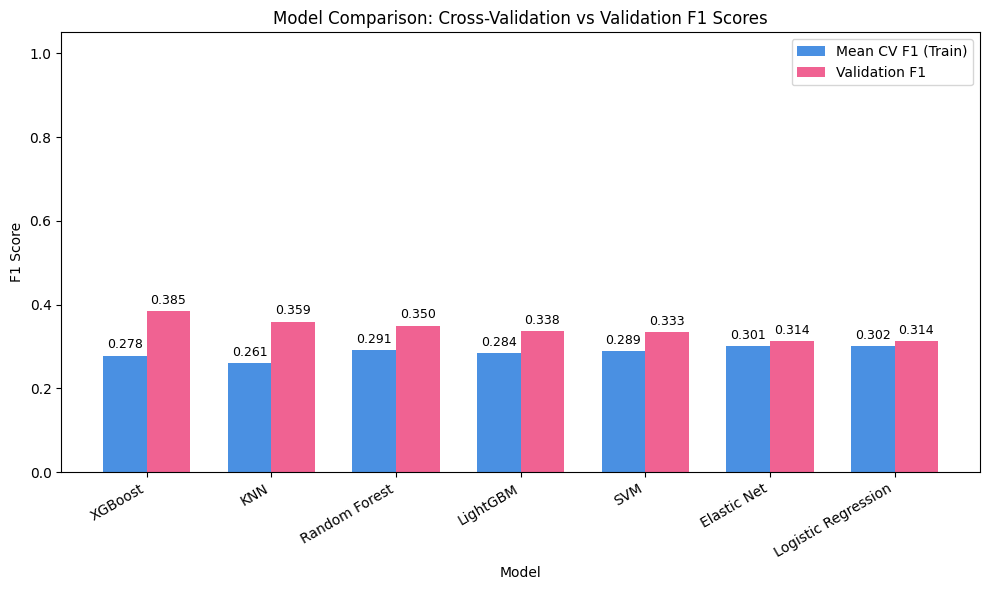

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(final_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, final_comparison["Mean CV F1"], width, label="Mean CV F1 (Train)", color="#4A90E2")
bars2 = ax.bar(x + width/2, final_comparison["Validation F1"], width, label="Validation F1", color="#F06292")

# add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_title("Model Comparison: Cross-Validation vs Validation F1 Scores")
ax.set_xticks(x)
ax.set_xticklabels(final_comparison["Model"], rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

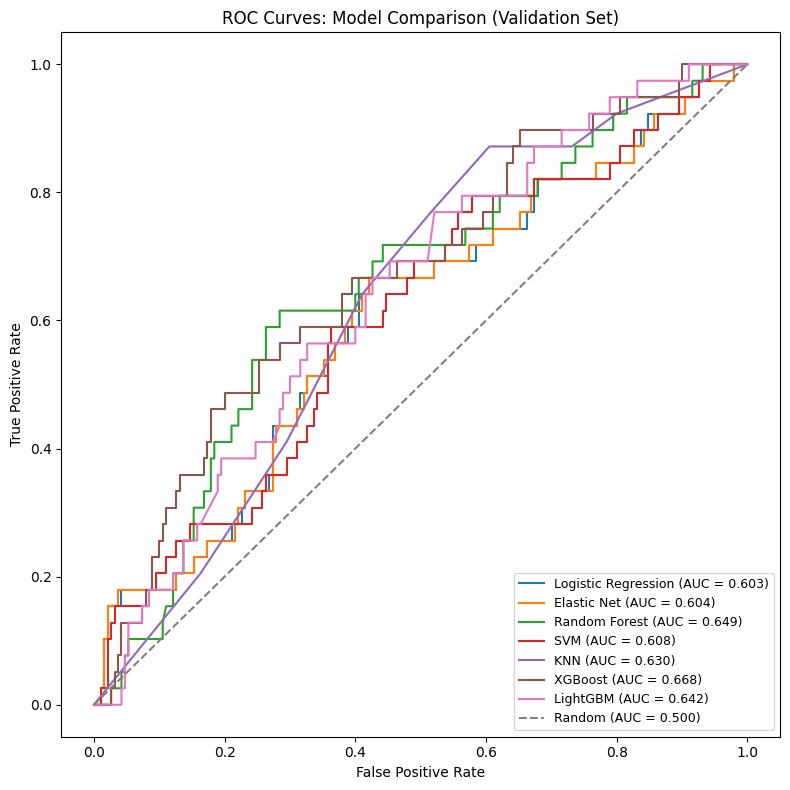

In [63]:
# fit AUC ROC curves for each model on the validation set
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 8))

for name, model in best_estimators.items():
    # use predicted probabilities for the positive class
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        # SVM with certain kernels may lack predict_proba; use decision_function instead
        y_proba = model.decision_function(X_val)

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)

    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Model Comparison (Validation Set)")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [64]:
# auc summary table
auc_results = []

for name, model in best_estimators.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = model.decision_function(X_val)

    auc_results.append({"Model": name, "Validation AUC": roc_auc_score(y_val, y_proba)})

auc_df = pd.DataFrame(auc_results).sort_values("Validation AUC", ascending=False).reset_index(drop=True)
auc_df

,Model,Validation AUC
0,XGBoost,0.668421
1,Random Forest,0.648516
2,LightGBM,0.642105
3,KNN,0.629555
4,SVM,0.607557
5,Elastic Net,0.603779
6,Logistic Regression,0.603239


XGBOSST selected



In [65]:
# SHAP analysis for the best performing model (based on validation F1) - XGBOOST
import shap

# extract the fitted XGBoost model from the pipeline
xgb_pipeline = best_estimators["XGBoost"]
xgb_model = xgb_pipeline.named_steps["model"]

# SHAP needs the actual feature data the model was trained on
# for tree models (unscaled), this is X_val directly
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

C:\Users\Ian Leboo\AppData\Local\Temp\ipykernel_1240\1074504278.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, show=True)


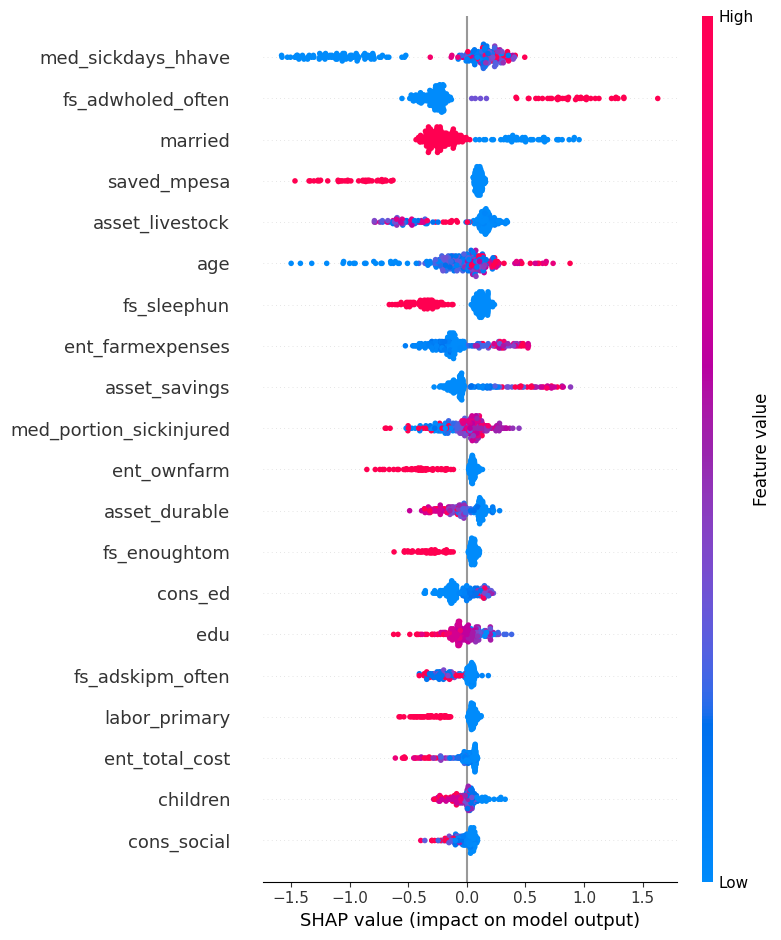

In [66]:
# shap global plot
shap.summary_plot(shap_values, X_val, show=True)

In [78]:
training_cols =  data.columns.tolist()

# filter test data to only include the features used in training
test_data_filtered = test_data[training_cols]
test_data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   femaleres                286 non-null    int64  
 1   age                      285 non-null    object 
 2   married                  286 non-null    int64  
 3   children                 286 non-null    int64  
 4   edu                      286 non-null    int64  
 5   hh_children              286 non-null    int64  
 6   asset_livestock          286 non-null    float64
 7   asset_durable            286 non-null    float64
 8   asset_phone              286 non-null    float64
 9   asset_savings            286 non-null    float64
 10  asset_land_owned_total   286 non-null    float64
 11  cons_allfood             286 non-null    float64
 12  cons_ownfood             286 non-null    float64
 13  cons_alcohol             274 non-null    float64
 14  cons_tobacco             2

In [79]:
# esnure age is not object
# drope these category rows
test_data_filtered['age'] = test_data_filtered['age'].astype('category')

# convert the rest to numeric, coercing errors to NaN
test_data_filtered['age'] = pd.to_numeric(test_data_filtered['age'], errors='coerce')

test_data_filtered.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   femaleres                286 non-null    int64  
 1   age                      284 non-null    float64
 2   married                  286 non-null    int64  
 3   children                 286 non-null    int64  
 4   edu                      286 non-null    int64  
 5   hh_children              286 non-null    int64  
 6   asset_livestock          286 non-null    float64
 7   asset_durable            286 non-null    float64
 8   asset_phone              286 non-null    float64
 9   asset_savings            286 non-null    float64
 10  asset_land_owned_total   286 non-null    float64
 11  cons_allfood             286 non-null    float64
 12  cons_ownfood             286 non-null    float64
 13  cons_alcohol             274 non-null    float64
 14  cons_tobacco             2

C:\Users\Ian Leboo\AppData\Local\Temp\ipykernel_1240\2469929905.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data_filtered['age'] = test_data_filtered['age'].astype('category')
C:\Users\Ian Leboo\AppData\Local\Temp\ipykernel_1240\2469929905.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data_filtered['age'] = pd.to_numeric(test_data_filtered['age'], errors='coerce')


In [95]:
# drop all rows where test deppressed is NA
test_data_filtered = test_data_filtered.dropna(subset=["depressed"])

# now select X and y in the test filter daat call them validate
X_validate = test_data_filtered.drop(columns=["depressed"])
y_validate = test_data_filtered["depressed"]

In [96]:
# predict on the filtered test data using the best XGBoost model
validate_predictions = xgb_pipeline.predict(X_validate)
validate_predictions

array([0, 0, 0, 1])

In [97]:
# Create a mask of rows where y_validate is NOT null
valid_mask = y_validate.notnull()

# Filter both the true labels and predictions using the mask
y_validate_clean = y_validate[valid_mask]
validate_predictions_clean = validate_predictions[valid_mask]

# use classification report to evaluate performance
from sklearn.metrics import classification_report

class_report = classification_report(y_validate_clean, validate_predictions_clean)

In [98]:
# Just print it directly to get a clean text table
print(class_report)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         3
         1.0       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Export the model and build a streamlit dashboard

In [ ]:
# Identify top 15 SHAP features and refit XGBoost on just these

# mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

top15_features = shap_importance.head(15)["feature"].tolist()
print(top15_features)

['med_sickdays_hhave', 'fs_adwholed_often', 'married', 'saved_mpesa', 'asset_livestock', 'age', 'fs_sleephun', 'ent_farmexpenses', 'asset_savings', 'med_portion_sickinjured', 'ent_ownfarm', 'asset_durable', 'fs_enoughtom', 'cons_ed', 'edu']


In [104]:
shap_importance

,feature,mean_abs_shap
34,med_sickdays_hhave,0.525115
29,fs_adwholed_often,0.390267
2,married,0.291728
42,saved_mpesa,0.268001
6,asset_livestock,0.267412
1,age,0.231975
32,fs_sleephun,0.218987
25,ent_farmexpenses,0.208421
9,asset_savings,0.174605
33,med_portion_sickinjured,0.152563


In [105]:
# top 15 features
shap_importance_top15 = shap_importance[shap_importance["feature"].isin(top15_features)].sort_values("mean_abs_shap", ascending=True)
shap_importance_top15

,feature,mean_abs_shap
4,edu,0.116438
16,cons_ed,0.122929
31,fs_enoughtom,0.123410
7,asset_durable,0.135067
19,ent_ownfarm,0.144737
33,med_portion_sickinjured,0.152563
9,asset_savings,0.174605
25,ent_farmexpenses,0.208421
32,fs_sleephun,0.218987
1,age,0.231975


In [100]:
# Refit final XGBoost model on top-15 features only (using best hyperparameters found earlier)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier

# best params found earlier for XGBoost
best_xgb_params = {
    k.replace("model__", ""): v
    for k, v in cv_results_df.set_index("Model").loc["XGBoost", "Best Params"].items()
}

X_train_top15 = X_train[top15_features]
X_val_top15 = X_val[top15_features]

final_pipeline = ImbPipeline([
    ("smote_enn", SMOTEENN(random_state=42)),
    ("model", XGBClassifier(eval_metric="logloss", random_state=42, **best_xgb_params))
])

final_pipeline.fit(X_train_top15, y_train)

# sanity check on validation set
from sklearn.metrics import classification_report
y_pred = final_pipeline.predict(X_val_top15)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.71      0.78       190
           1       0.26      0.51      0.35        39

    accuracy                           0.67       229
   macro avg       0.57      0.61      0.56       229
weighted avg       0.77      0.67      0.71       229



In [103]:
# save the model
import joblib

# bundle everything the app needs
model_bundle = {
    "pipeline": final_pipeline,
    "features": top15_features,
    "feature_descriptions":{
        'med_sickdays_hhave': 'Average number of sick days per HH member',
        'fs_adwholed_often': 'Whole days without food (adults, \# last month)', 
        'married': 'Marital status',
        'saved_mpesa': 'Saved money in M-Pesa',
        'asset_livestock': 'Value of livestock (USD)',
        'age': 'Age',
        'fs_sleephun': 'Slept hungry (At least once last week)',
        'ent_farmexpenses': 'Farm flow expenses, monthly (USD)',
        'asset_savings': 'Value of savings (USD)',
        'med_portion_sickinjured': 'Proportion of household sick/injured (1 month)',
        'ent_ownfarm': 'Own farm primary income',
        'asset_durable': 'Value of durable goods (USD)',
        'fs_enoughtom': 'Enough food to eat tomorrow',
        'cons_ed': 'Education expenditure (USD)',
        'edu': 'Years of education completed'
    }
        
}

joblib.dump(model_bundle, "../models/depression_model_bundle.pkl")
print("Saved model bundle.")

Saved model bundle.


<>:10: SyntaxWarning: "\#" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\#"? A raw string is also an option.
<>:10: SyntaxWarning: "\#" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\#"? A raw string is also an option.
C:\Users\Ian Leboo\AppData\Local\Temp\ipykernel_1240\440300099.py:10: SyntaxWarning: "\#" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\#"? A raw string is also an option.
  'fs_adwholed_often': 'Whole days without food (adults, \# last month)',


## Streamlit app setup

## Model Deployment: Streamlit Application

To make the trained model accessible and interpretable for non-technical end users (e.g., community health workers or program staff), the final XGBoost model — restricted to its top 15 SHAP-ranked features — was deployed as an interactive web application using **Streamlit**.

The application allows a user to input a respondent's survey responses across five domains (demographics, food security, household assets/economics, farming activity, and health indicators) via sliders, radio buttons, and numeric inputs tailored to each variable's definition and plausible range. On submission, the app returns:

- The model's estimated probability that the respondent meets the threshold for moderate depression
- A categorical risk tier (Low / Medium / High), derived from the predicted probability
- A plain-language flag indicating whether follow-up may be warranted
- An individualized SHAP explanation, presented as a bar chart, showing which of the respondent's specific inputs increased or decreased their predicted risk

The model bundle (trained pipeline, selected features, and human-readable feature labels) was serialized using `joblib` and loaded by the application at runtime. The app includes an explicit disclaimer that it is intended for portfolio/educational purposes and prioritization support only, and is not a diagnostic instrument.

The application can be run locally via:

```bash
streamlit run app/streamlit_app.py
```

### Requirements

| Package | Purpose |
|---|---|
| `streamlit` | Web application framework for the interactive interface |
| `pandas` | Data manipulation and input formatting |
| `numpy` | Numerical operations |
| `scikit-learn` | Preprocessing pipeline components (scaling, imputation) |
| `imbalanced-learn` | SMOTE-ENN resampling within the model pipeline |
| `xgboost` | Final classification model |
| `lightgbm` | Required for unpickling the model comparison pipeline objects |
| `shap` | Per-individual feature contribution explanations |
| `matplotlib` | SHAP contribution chart rendering |
| `joblib` | Loading the serialized model bundle |


A note on `lightgbm` in the requirements: it's only needed if your saved bundle/pipeline object retains any reference to LightGBM internals from earlier model comparisons (unlikely if `model_bundle` only contains the final XGBoost pipeline). If your bundle is purely XGBoost-based, you can drop it from the app's requirements — but it's harmless to leave in if you're unsure, since the main `requirements.txt` for the whole project will need it anyway for the modeling notebook.